### ***Project # 3***

#### ***Objective***

* To predict whether a liability customer will buy a personal loan or not.
* Which variables are most significant.
* Which segment of customers should be targeted more.

#### ***Data Dictionary***
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign?
* `Securities_Account`: Does the customer have securities account with the bank?
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank?
* `Online`: Do customers use internet banking facilities?
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)?

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# libraries to build Logistic Regression
from sklearn.linear_model import LogisticRegression

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option("display.max_columns", None)  # Removes the limit for the number of displayed columns
pd.set_option("display.max_rows", 200)  # Sets the limit for the number of displayed rows

In [2]:
# read dataset and check the header
loan = pd.read_csv("data/23_Loan_Modelling.csv")
loan.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
# check the tail
loan.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


* ID column can be deleted since its a sequence number

In [4]:
loan.drop(columns=["ID"], inplace=True)

In [5]:
# check the shape
loan.shape

(5000, 13)

* There are 5000 rows and 13 columns

In [6]:
# check data type
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


* All the columns are numeric
* There are no null values 

In [7]:
# explore zipcode
loan["ZIPCode"].nunique()

467

* There are 467 unique zipcodes, which will need to be converted into higher level categoy

In [8]:
loan["Personal_Loan"].value_counts(normalize=True)

Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64

* Close to 10% of customer accepted personal loan offer

#### Summary of Dataset

In [9]:
loan.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


* Average age of the customer is 45.38
* Average professional experience is around 20 years, minimum value of experience is negative, will need to explore further
* Average income is 73.77K which is higher than median income of 64K, income is right skewed
* Family seems to be categorical variable with min 1 member and max 4 member
* Average spending on Credit card is 1.94K per month. There are customers with zero Credit card spent
* Education seems to be categorical variable based on definition provided
* Mortgage is again right skewed. There are customers with zero Mortgage. 
* Other variables are categical variable

#### Check for missing values

In [10]:
loan.isnull().sum()

Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

#### Check for duplicate values

In [11]:
loan.duplicated().sum()

np.int64(0)

#### Check negative experience records

In [12]:
loan[loan["Experience"] < 0].shape

(52, 13)

* There are 52 customers who have negative experience. In reality, this will not be possible, so lets replace these with zero 

In [13]:
# convert negative into zero

def negative_to_zero(exp_val):
    if exp_val < 0:
        return 0
    else:
        return exp_val


loan["Experience"] = loan["Experience"].apply(negative_to_zero)

In [14]:
loan[loan["Experience"] < 0].shape

(0, 13)

#### dropping zipcode from the dataset

In [15]:
loan.drop(columns=["ZIPCode"], inplace=True)

### Exploratory Data Analysis

#### Univariate Analysis

**Helper Function to plot Numerical and Categorical Features**

In [16]:
# Function to plot count and percentage barplots side by side for categorical features for Univariate Analysis
def cat_analysis_count_and_perct(data, column, figsize=(10, 5)):
    """
    Plots two countplots side by side: one with count labels, one with percentage labels.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plots.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)
    
    # Countplot with count labels
    ax1 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[0], palette='Set2')
    axes[0].set_title('Counts per ' + column)
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=90)
    for p in ax1.patches:
        count = int(p.get_height())
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='black')
    
    # Countplot with percentage labels
    ax2 = sns.countplot(data=data, x=column, hue=column, order=categories, ax=axes[1], palette='Set2')
    axes[1].set_title('Percentage per ' + column)
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Percentage')
    axes[1].tick_params(axis='x', rotation=90)
    for p in ax2.patches:
        percent = 100 * p.get_height() / total
        ax2.annotate(f'{percent:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, color='blue')
    
    plt.tight_layout()
    plt.show()

In [17]:
# Function to create a histogram and boxplot combined for visualization of numerical features for Univariate Analysis
def num_analysis_hist_box(data, feature, figsize=(10, 5)):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize)  # creating the 2 subplots
    
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="lightgreen")  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2, color='skyblue')  # For histogram
    
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")  # Add median to the histogram

#### Observation on Personal Loan

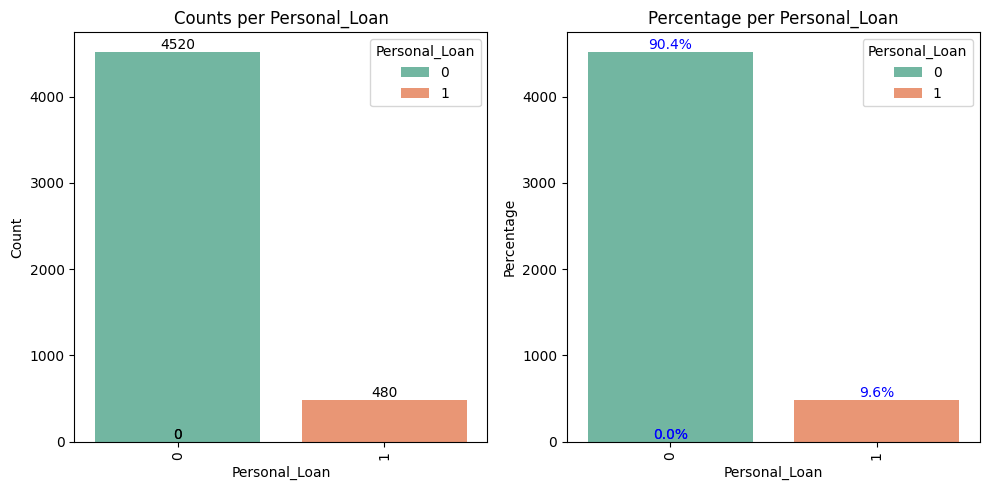

In [18]:
cat_analysis_count_and_perct(loan, "Personal_Loan")

*Approximately 10% of customers accepted personal loan*

#### Observation on Family

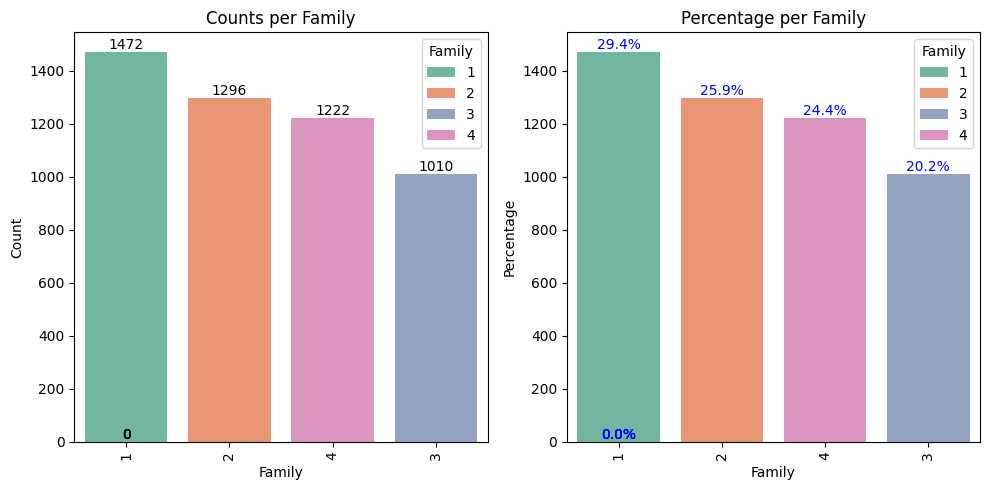

In [19]:
cat_analysis_count_and_perct(loan, "Family")

*Majority of customers are single, followed by couples and family of four*

#### Observation on Education

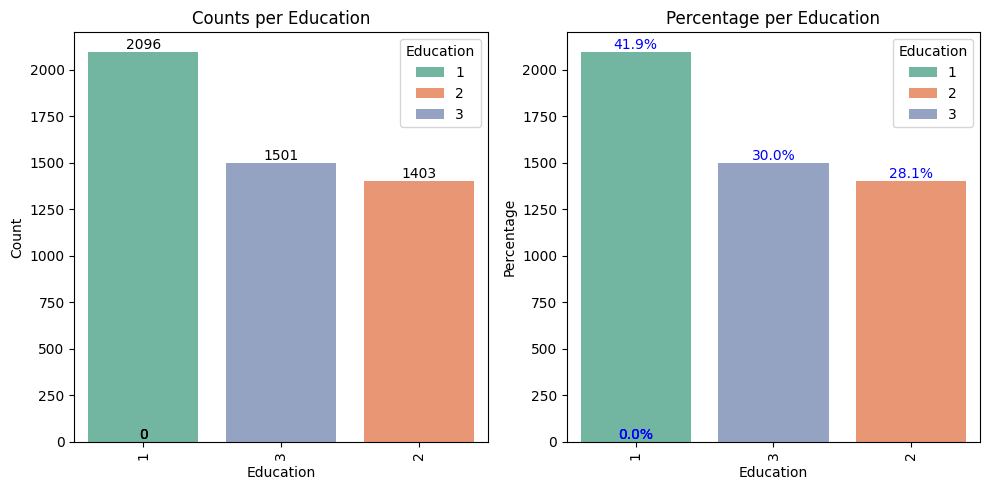

In [20]:
cat_analysis_count_and_perct(loan, "Education")

*Majority (41.9%) of customers are undergraduate, followed by Advanced/professional (30%)*

#### Observation on Securities Account

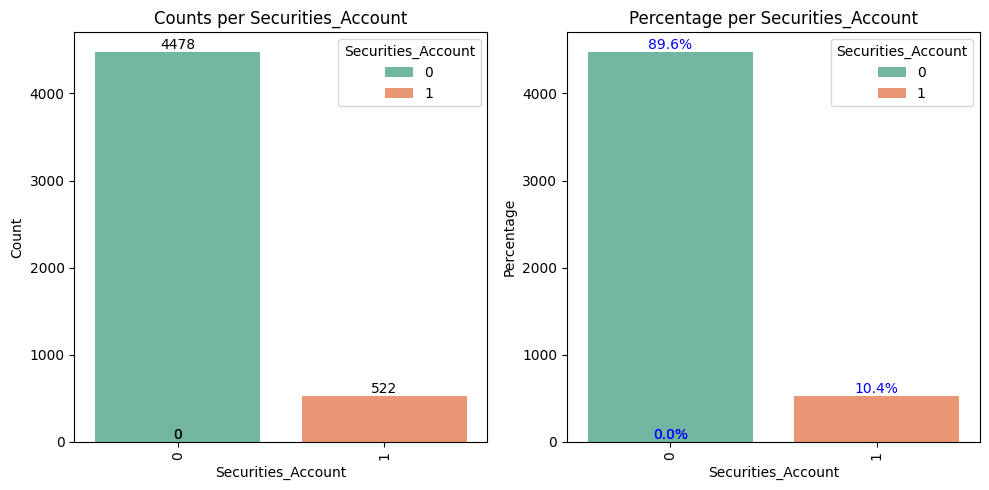

In [21]:
cat_analysis_count_and_perct(loan, "Securities_Account")

*Almost 90% of customers do not have security account with the bank*

#### Observation on Certificate of Deposit Account

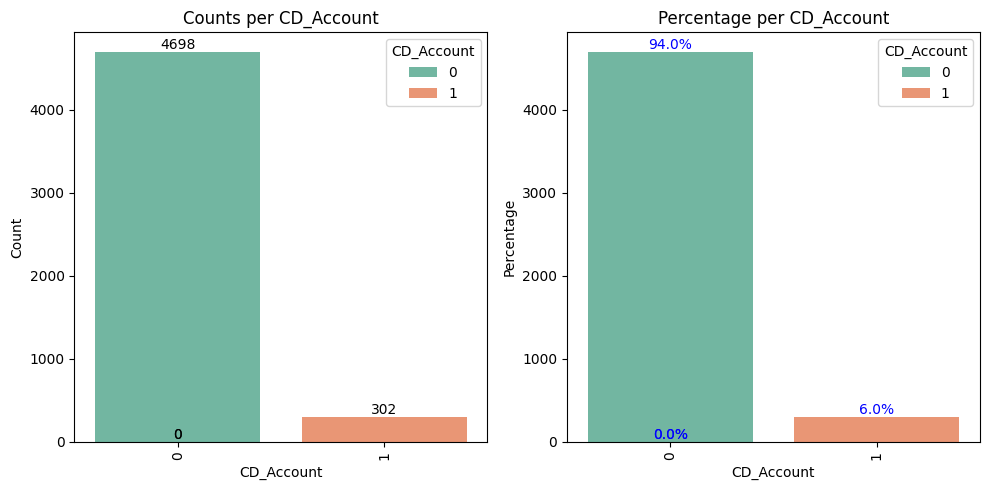

In [22]:
cat_analysis_count_and_perct(loan, "CD_Account")

*Almost 94% of customers do not have Certificate of Deposit Account with the bank*

#### Observation on Internet Banking Facilities

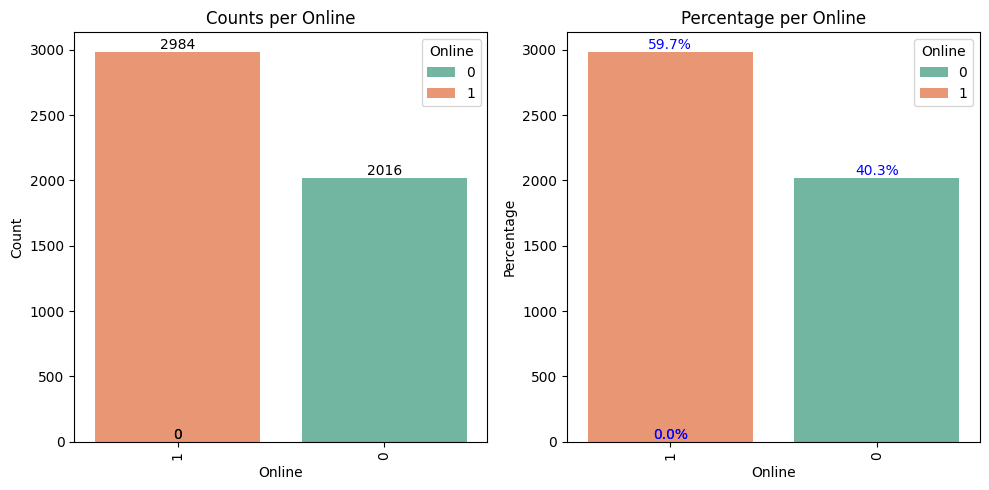

In [23]:
cat_analysis_count_and_perct(loan, "Online")

*Almost 60% of the customers use internet banking facilities*

#### Observation on Credit Card by other Banks

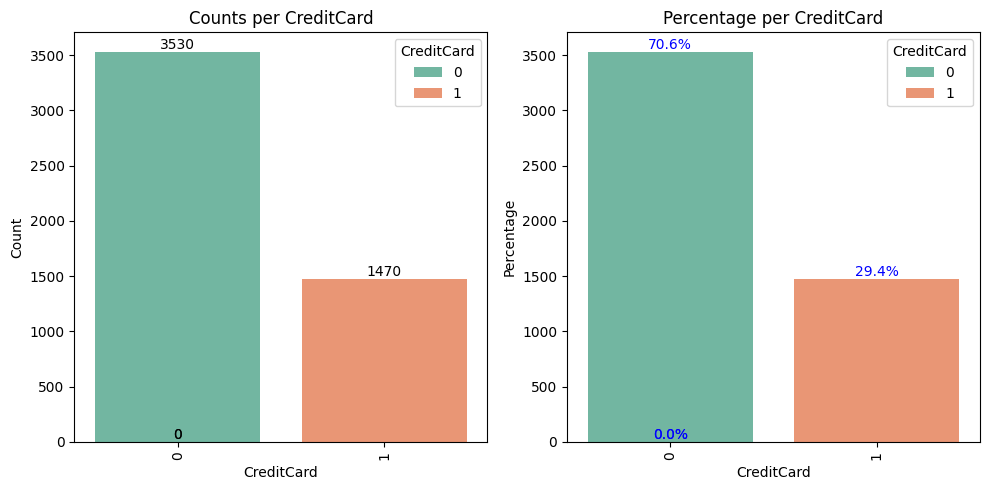

In [24]:
cat_analysis_count_and_perct(loan, "CreditCard")

*Almost 29% of the customers use credit card issued by other bank*

#### Obervation on Age

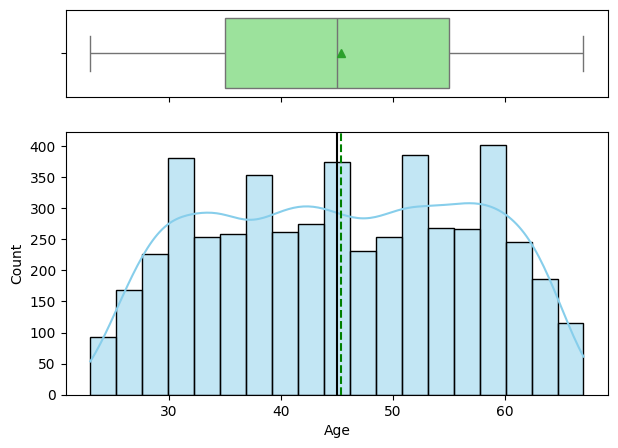

In [25]:
num_analysis_hist_box(loan, "Age", (7, 5))

*Most of the customers are in the range 30 to 60 years with no outliers*

#### Obervation on Income

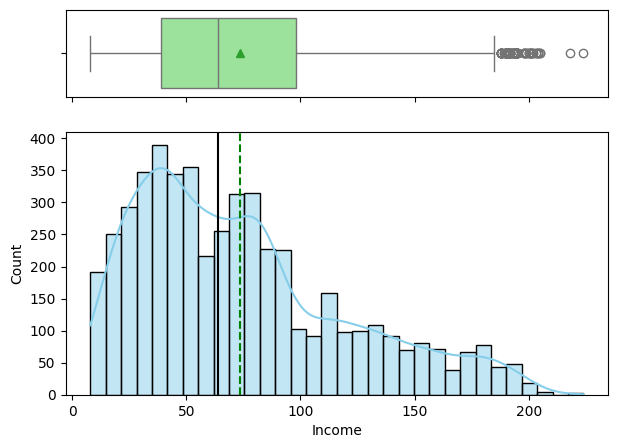

In [26]:
num_analysis_hist_box(loan, "Income", (7, 5))

*Income is right skewed with many outliers at the higher income side*

#### Obervation on Mortgage

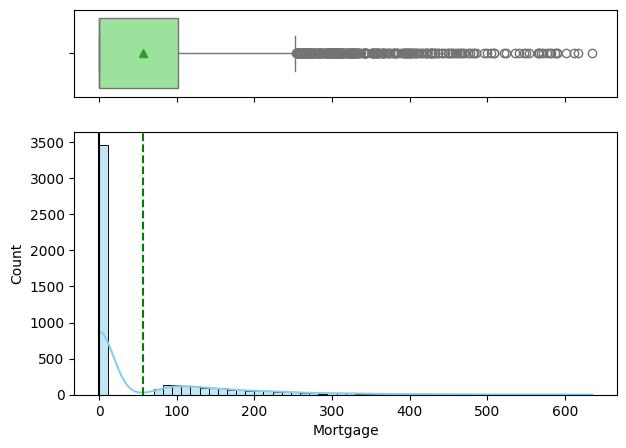

In [27]:
num_analysis_hist_box(loan, "Mortgage", (7, 5))

*Looks like there are high number of customers (just less than 3500) who do not have house mortgage, Data is right skewed with many outliers*

#### Obervation on # of years of Professional Experience

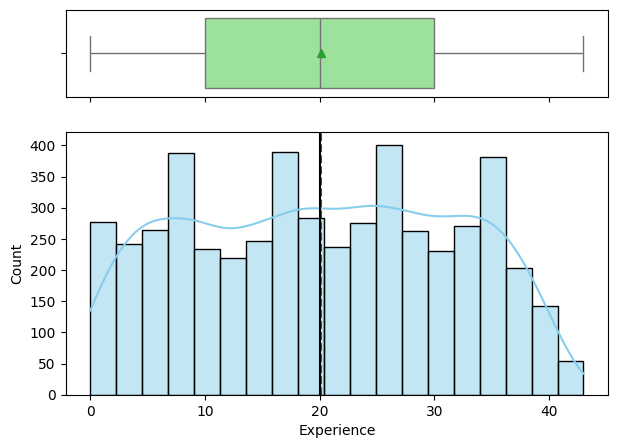

In [28]:
num_analysis_hist_box(loan, "Experience", (7, 5))

*There are no outliers. good spread of customer experience from 0 to 40 years*

#### Obervation on Average spending on credit cards per month

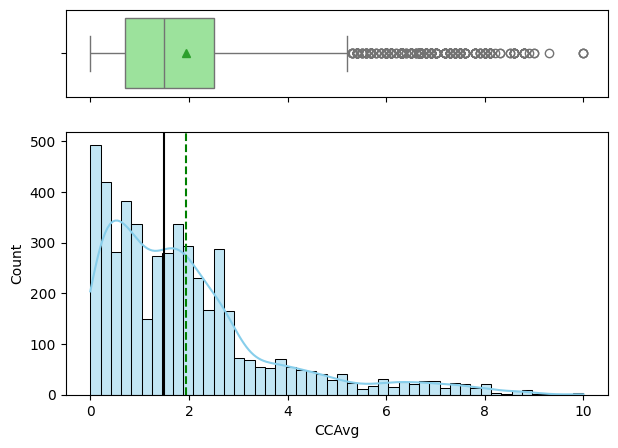

In [29]:
num_analysis_hist_box(loan, "CCAvg", (7, 5))

*Data is right skewed with many outliers*

### Multivariate Analysis

**Helper Function**

In [30]:
# Function to plot target distribution by category with percentage labels on stacked bar segments
def target_distribution_by_category(data, x_col, hue_col, colormap='tab20', figsize=(6, 4), title=None):
    """
    Plots a stacked bar chart showing percentage distribution of hue_col within each x_col category,
    with percentage labels on each segment.
    """
    # Group and calculate percentages
    grouped = data.groupby([x_col, hue_col]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

    # Plot
    ax = percentages.plot(kind='bar', stacked=True, figsize=figsize, colormap=colormap)

    # Add percentage labels
    for i, (index, row) in enumerate(percentages.iterrows()):
        cum_height = 0
        for j, value in enumerate(row):
            if value > 0:
                ax.text(
                    i,                      # x position
                    cum_height + value / 2, # y position (middle of the bar segment)
                    f'{value:.1f}%',        # label text
                    ha='center', va='center', fontsize=8, color='white'
                )
                cum_height += value

    plt.ylabel('Percentage')
    plt.title(title or f'{x_col} Distribution by {hue_col} (Stacked Percentage)')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [31]:
### function to plot distributions wrt target
def num_feature_vs_target(data, predictor, target):
    sns.boxplot(data=data, x=target, y=predictor, palette="Set2", hue=target, showfliers=False);
    plt.title(f'{predictor} distribution by {target}');
    plt.tight_layout()
    plt.show()

#### Target Variable Personal Loan vs Family

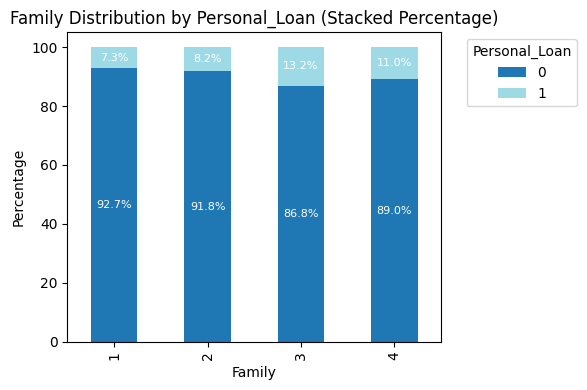

In [32]:
target_distribution_by_category(loan, "Family", "Personal_Loan")

*Family with 4 and 3 members took more personal loans*

#### Target Variable Personal Loan vs Education

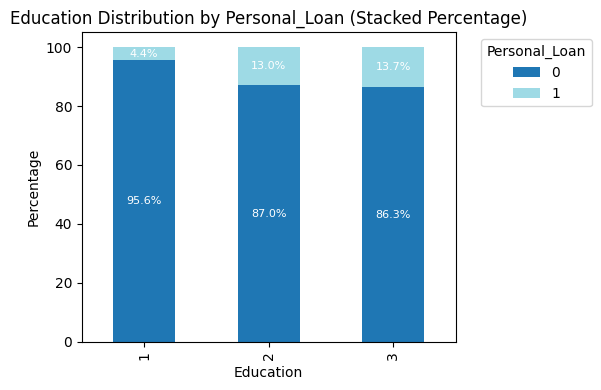

In [33]:
target_distribution_by_category(loan, "Education", "Personal_Loan")

*Customers who are undergrads did not take personal loans as much as compared with customers who are graduates and have advanced degrees*

#### Target Variable Personal Loan vs Securities Account

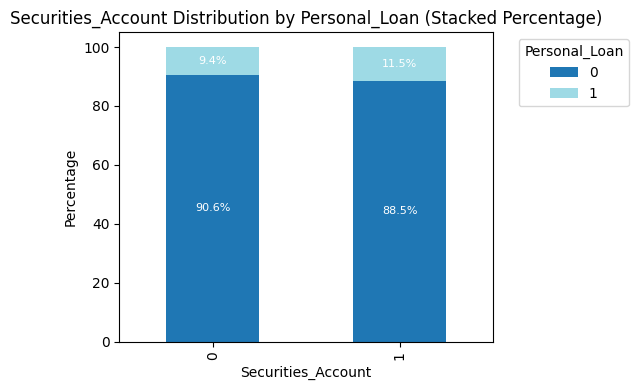

In [34]:
target_distribution_by_category(loan, "Securities_Account", "Personal_Loan")

*Based on the data, customers with securities account, are more likely to take personal loan*

#### Target Variable Personal Loan vs Certificate of Deposit

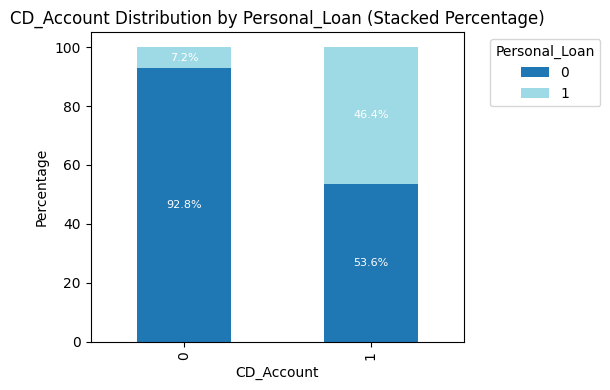

In [35]:
target_distribution_by_category(loan, "CD_Account", "Personal_Loan")

*Based on the data, customers with certificate of deposit account, are more likely to take personal loan*

#### Target Variable Personal Loan vs Online Customers

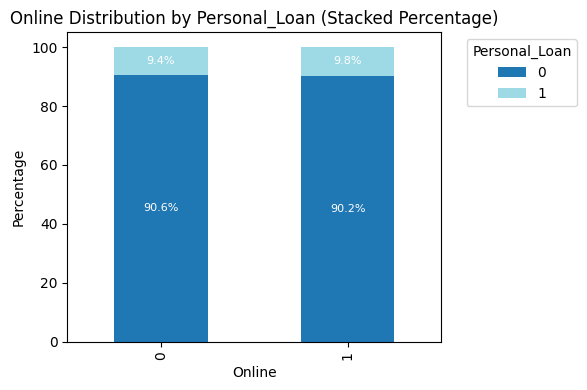

In [36]:
target_distribution_by_category(loan, "Online", "Personal_Loan")

*There is not much difference if the customer is online on their personal loan*

#### Target Variable Personal Loan vs Credit Card

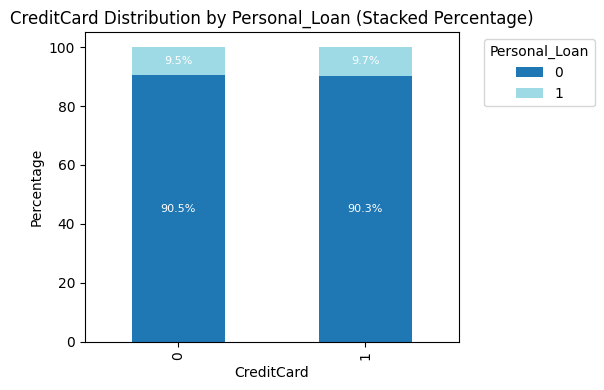

In [37]:
target_distribution_by_category(loan, "CreditCard", "Personal_Loan")

*There is not much difference if the customer is using other Bank's credit card on personal loan*

#### Target Variable vs Age

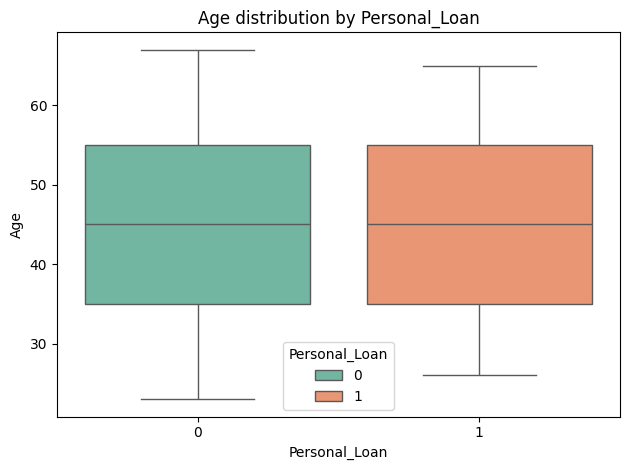

In [38]:
num_feature_vs_target(loan, "Age", "Personal_Loan")

*Range of Age is slightly smaller for customers who took personal loan*

#### Target Variable vs Experience

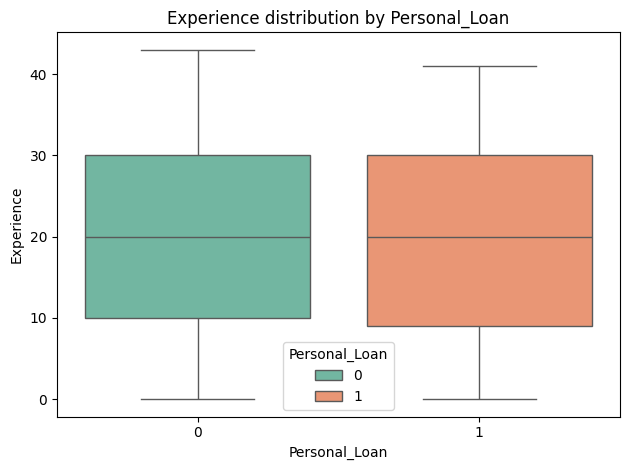

In [39]:
num_feature_vs_target(loan, "Experience", "Personal_Loan")

*Range of Experience is smaller for customers who took personal loan*

#### Target Variable vs Income

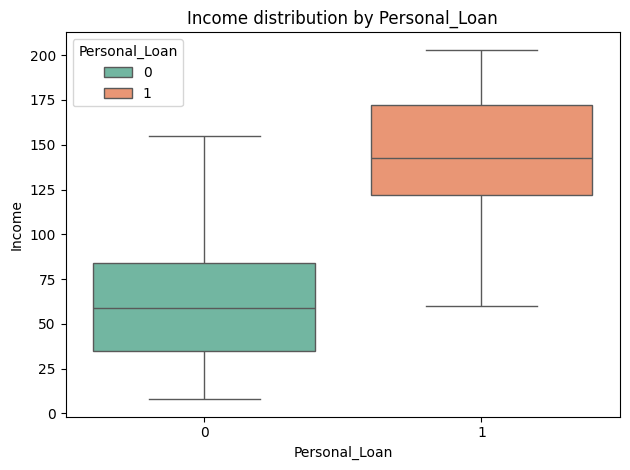

In [40]:
num_feature_vs_target(loan, "Income", "Personal_Loan")

*Higher Income customers took more Personal Loans*

#### Target Variable vs Credit Card spent per month

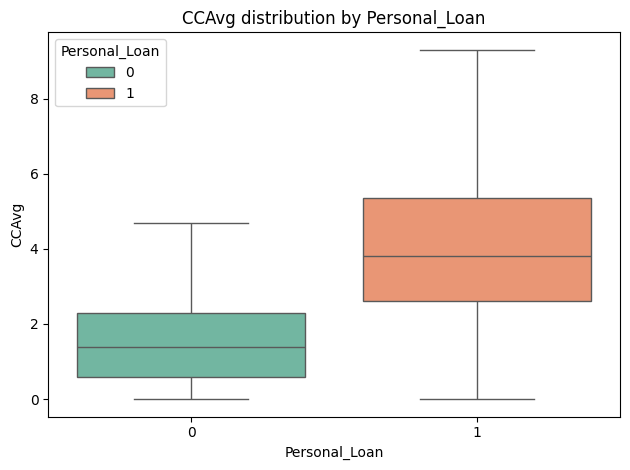

In [41]:
num_feature_vs_target(loan, "CCAvg", "Personal_Loan")

*High credit card spenders in a month took more Personal Loans*

#### Target Variable vs Mortgage

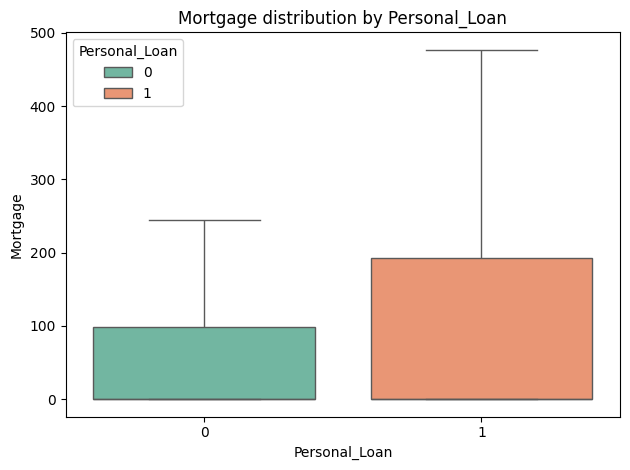

In [42]:
num_feature_vs_target(loan, "Mortgage", "Personal_Loan")

*Customers who have mortgage took more Personal Loans*

#### relations between different continuous variables

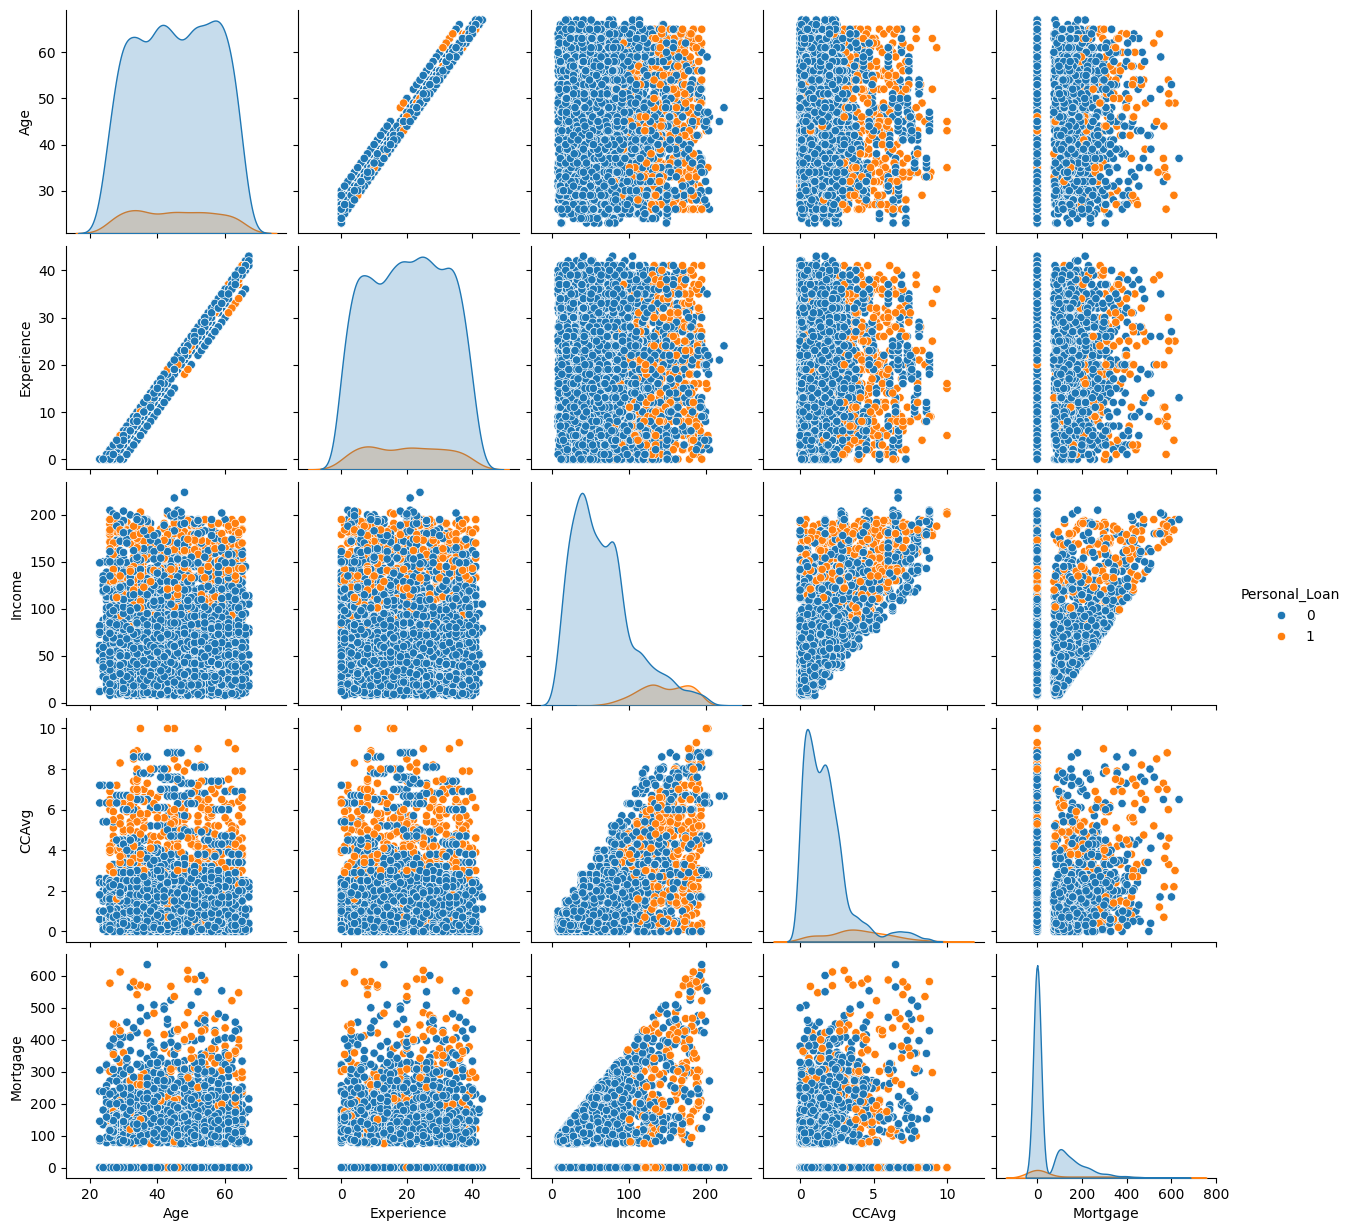

In [43]:
sns.pairplot(
    data=loan,
    vars=["Age", "Experience", "Income", "CCAvg", "Mortgage"],
    hue="Personal_Loan",
);

* Higher the income and Credit card usage, greater chance of personal loan
* There is positive coorelation between Experience and Age, Income and Mortgage, Income and Credit card usage

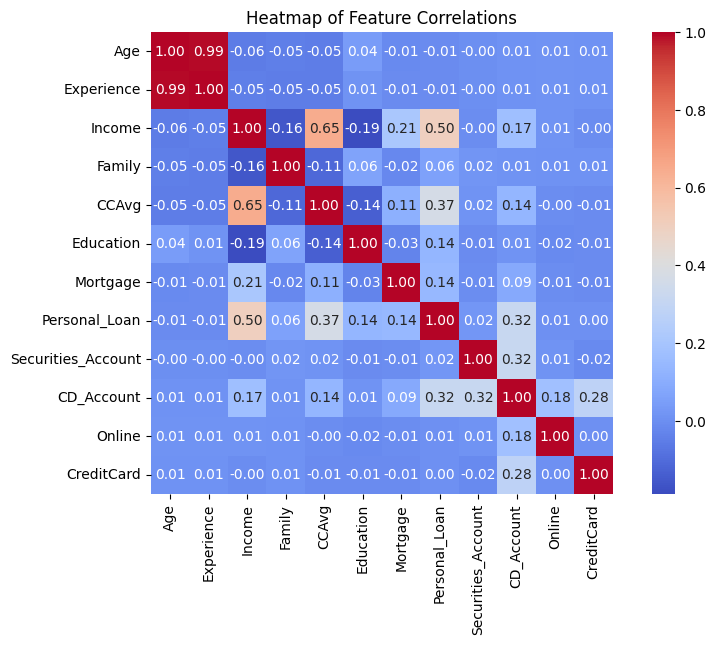

In [44]:
# heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(loan.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap of Feature Correlations")
plt.show()

*Looking at the Target Variable `Personal_Loan`, Features like `Income`, `CD_Account`, `CCAvg` seems to have some correlation*

### Data PreProcessing

In [45]:
# Convert Family, Education, Personal_Loan, Securities_Account, CD_Account, Online,
# CreditCard into category based on information provided

loan["Family"] = loan["Family"].astype("category")
loan["Education"] = loan["Education"].astype("category")
loan["Personal_Loan"] = loan["Personal_Loan"].astype("category")
loan["Securities_Account"] = loan["Securities_Account"].astype("category")
loan["CD_Account"] = loan["CD_Account"].astype("category")
loan["Online"] = loan["Online"].astype("category")
loan["CreditCard"] = loan["CreditCard"].astype("category")

#### Outlier Detection using boxplot

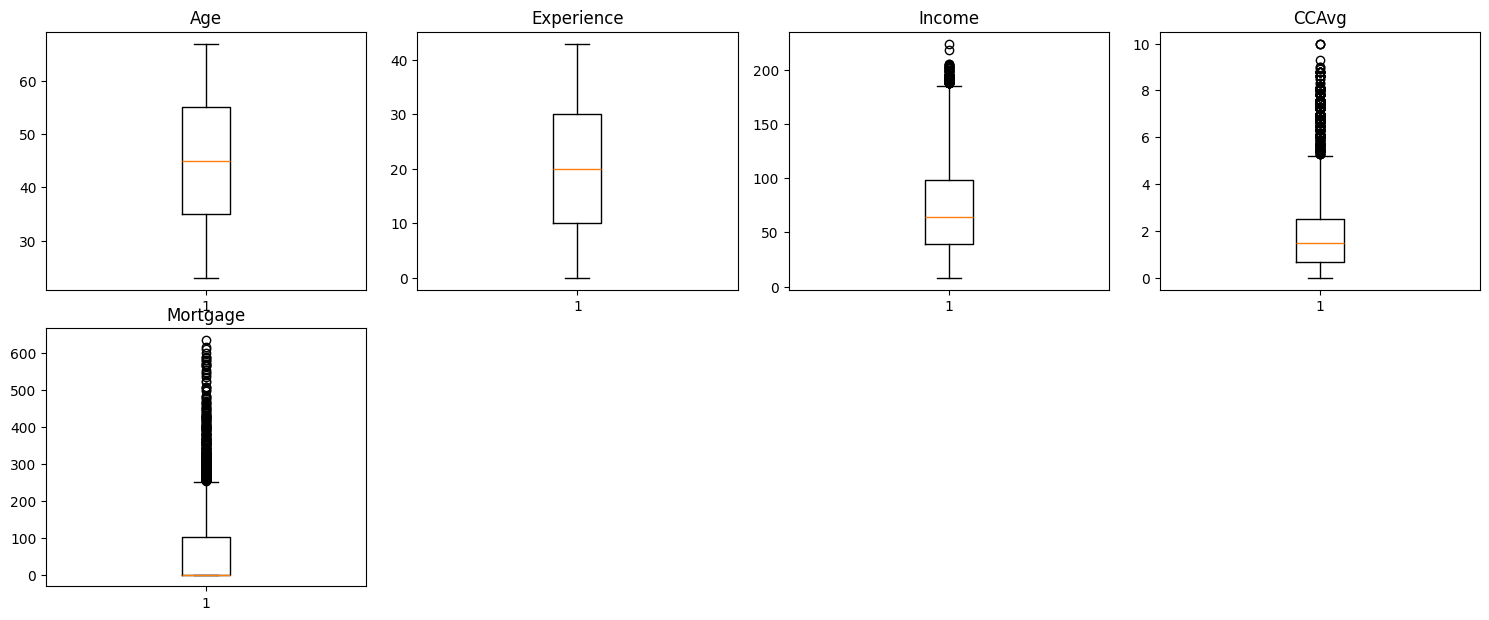

In [46]:
num_cols = loan.columns[loan.dtypes != "category"]

plt.figure(figsize=(15, 12))

for i, variable in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(loan[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* Age and Experience do not have any outliers
* Income, Credit Card Avg and Mortgage have outliers at the higher side

In [47]:
# lets find %age of outliers
Q1 = loan[num_cols].quantile(0.25)
Q3 = loan[num_cols].quantile(0.75)

IQR = Q3 - Q1

# Finding lower and upper bounds for all values. All values outside these bounds are outliers
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Percentage of outliers in each column
(
    (loan[num_cols] < lower_whisker) | (loan[num_cols] > upper_whisker)
).sum() / loan.shape[0] * 100

Age           0.00
Experience    0.00
Income        1.92
CCAvg         6.48
Mortgage      5.82
dtype: float64

* Credit card average per month and Mortgage have higher %age of outliers, but they seems fine looking at numbers (from describe())

### Model Building

In [48]:
X = loan.drop(["Personal_Loan"], axis=1)

# creating dummy variables
X = pd.get_dummies(X, drop_first=True)

y = loan["Personal_Loan"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [50]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 3500
Number of rows in test data = 1500


In [51]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


#### Logistic Regression

In [52]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [53]:
# defining a function to plot the confusion_matrix of a classification model built using sklearn
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

#### Logistic Regression using liblinear

In [54]:
# fit the model on training data
lg = LogisticRegression(solver="liblinear", random_state=1)
lg.fit(X_train, y_train)
lg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 1,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

#### Finding the coefficients and its interpretation

In [55]:
pd.DataFrame(lg.coef_[0], X_train.columns, columns=["coeff"]).T

,Age,Experience,Income,CCAvg,Mortgage,Family_2,Family_3,Family_4,Education_2,Education_3,Securities_Account_1,CD_Account_1,Online_1,CreditCard_1
coeff,-0.365653,0.365389,0.053616,0.205181,0.000835,-0.191633,1.997875,1.288925,3.21429,3.510881,-0.802716,2.994958,-0.512041,-0.819817


* Coefficients of Experience, Income, CC Average, Mortgage, Family of 3 and 4, higher education, Certificate of deposit are positive, an increase in these will lead to an increase in chances of a customer taking personal loan
* Coefficients of Age, Family of 2, securities account holder, online banking, other bank credit card are negative, an increase in these will lead to a decrease in chances of a customer taking personal loan

In [56]:
# converting coefficients to odds
odds = np.exp(lg.coef_[0])

# %age change
perc_change_odds = (np.exp(lg.coef_[0]) - 1) * 100

# dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).T

,Age,Experience,Income,CCAvg,Mortgage,Family_2,Family_3,Family_4,Education_2,Education_3,Securities_Account_1,CD_Account_1,Online_1,CreditCard_1
Odds,0.693743,1.441074,1.055079,1.227747,1.000835,0.825610,7.373368,3.628884,24.885625,33.477740,0.448110,19.984528,0.599271,0.440512
Change_odd%,-30.625655,44.107414,5.507939,22.774694,0.083533,-17.439003,637.336813,262.888415,2388.562469,3247.773954,-55.188964,1898.452839,-40.072851,-55.948786


* Age: Holding all other features constant, a unit change in Age will decrease the odds of a customer taking personal loan by 0.69 times or 30.62% decrease in the odds 
* Experience: Holding all other features constant, a unit change in Experience will increase the odds of a customer taking personal loan by 1.44 times or 44.1% increase in odds
* Income: Holding all other features constant, a unit change in Income will increase the odds of a customer taking personal loan by 1.05 or 5.5% increase in the odds
* CCAvg: Holding all other features constant, a unit change in CC Avg will increase the odds of a customer taking personal loan by 1.22 times or 22.77% increase in the odds. 
* Mortgage: Holding all other features constant, a unit change in Mortgage will increase the odds of a customer taking personal loan by 1 times or 0.08% increase in odds. 

#### Model Performance

Training Metrics
   Accuracy    Recall  Precision        F1
0  0.960286  0.679758   0.872093  0.764007


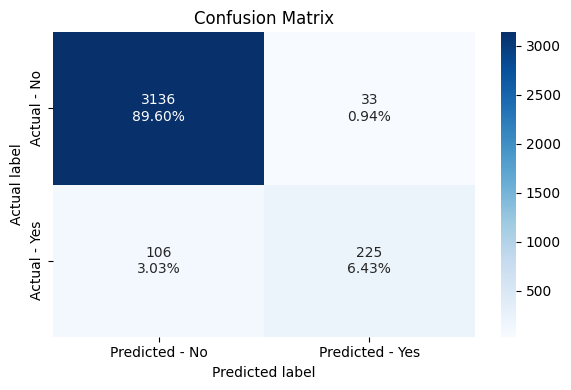

In [57]:
print("Training Metrics")
log_reg_model_class_train_perf = model_performance_classification_sklearn(
    lg, X_train, y_train
)
print(log_reg_model_class_train_perf)
confusion_matrix_sklearn(lg, X_train, y_train)

Testing Metrics
   Accuracy    Recall  Precision        F1
0  0.952667  0.597315       0.89  0.714859


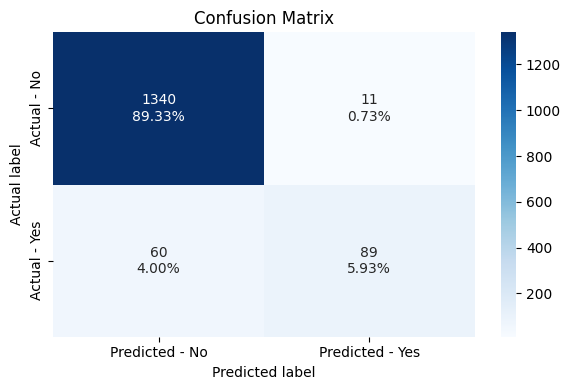

In [58]:
print("Testing Metrics")
log_reg_model_class_test_perf = model_performance_classification_sklearn(
    lg, X_test, y_test
)
print(log_reg_model_class_test_perf)
confusion_matrix_sklearn(lg, X_test, y_test)

* Accurancy, Recall, Precision and F1 are pretty comparable for both training and test sets

### ROC-AUC

functions to print performance metrics and confusion metrics using threshold

In [59]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn_with_threshold(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics, based on the threshold specified, to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    # predicting using the independent variables
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    pred = np.round(pred_thres)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )
    return df_perf

In [60]:
# defining a function to plot the confusion_matrix of a classification model built using sklearn
def confusion_matrix_sklearn_with_threshold(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix, based on the threshold specified, with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    pred_prob = model.predict_proba(predictors)[:, 1]
    pred_thres = pred_prob > threshold
    y_pred = np.round(pred_thres)

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

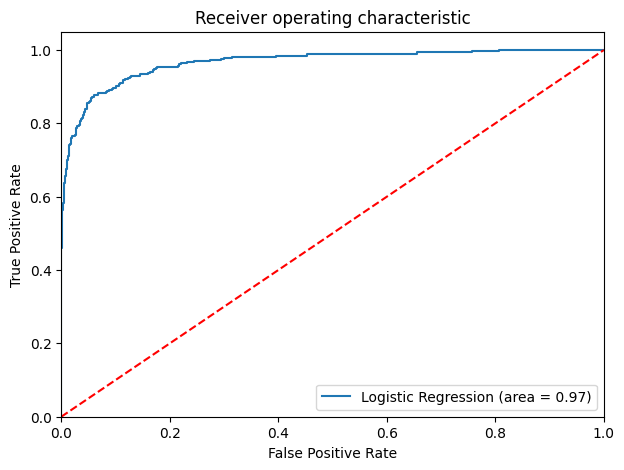

In [61]:
logit_roc_auc_train = roc_auc_score(y_train, lg.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, lg.predict_proba(X_train)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [62]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lg.predict_proba(X_train)[:, 1])

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.16136772170234387


Training Confusion Matrix


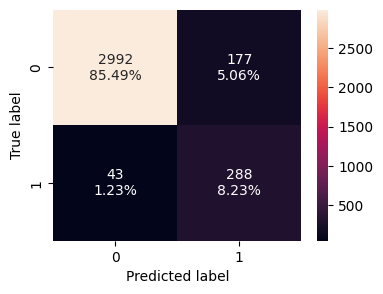

In [63]:
# creating confusion matrix
print("Training Confusion Matrix")
confusion_matrix_sklearn_with_threshold(
    lg, X_train, y_train, threshold=optimal_threshold_auc_roc
)

In [64]:
# checking model performance for this model
log_reg_model_train_perf_threshold_auc_roc = (
    model_performance_classification_sklearn_with_threshold(
        lg, X_train, y_train, threshold=optimal_threshold_auc_roc
    )
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.937143,0.870091,0.619355,0.723618


Testing Confusion Matrix


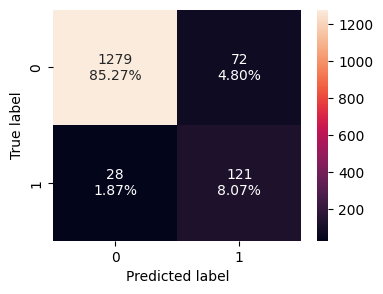

In [65]:
# creating confusion matrix
print("Testing Confusion Matrix")
confusion_matrix_sklearn_with_threshold(
    lg, X_test, y_test, threshold=optimal_threshold_auc_roc
)

In [66]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = (
    model_performance_classification_sklearn_with_threshold(
        lg, X_test, y_test, threshold=optimal_threshold_auc_roc
    )
)
print("Testing performance:")
log_reg_model_test_perf_threshold_auc_roc

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.933333,0.812081,0.626943,0.707602


#### Use Precision-Recall curve to see if we can get better threshold

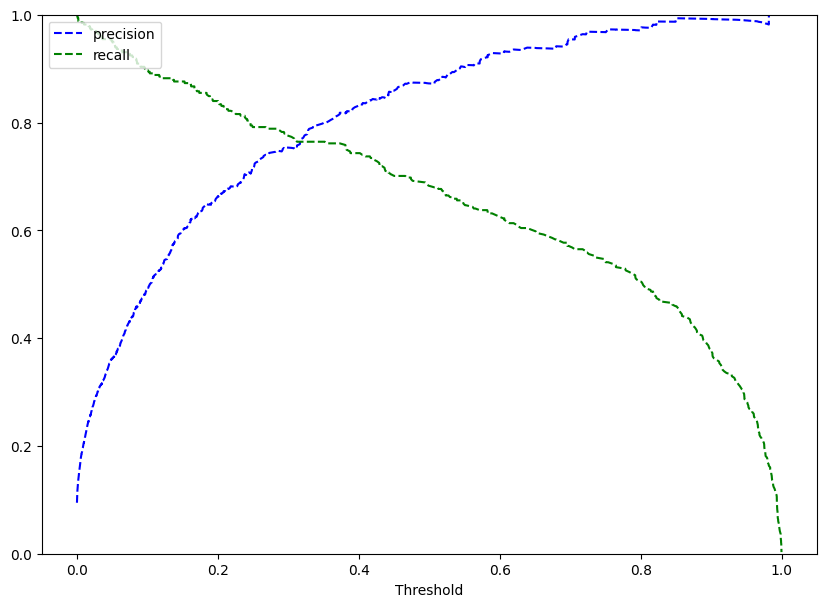

In [67]:
y_scores = lg.predict_proba(X_train)[:, 1]
prec, rec, tre = precision_recall_curve(
    y_train,
    y_scores,
)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

use threshold around 0.35 and check the recall/precision for both training and testing data

Training Confusion Matrix


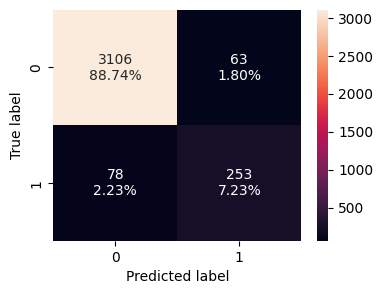

In [68]:
# creating confusion matrix
print("Training Confusion Matrix")
confusion_matrix_sklearn_with_threshold(lg, X_train, y_train, threshold=0.35)

In [69]:
# checking model performance for this model
log_reg_model_train_perf_threshold_curve = (
    model_performance_classification_sklearn_with_threshold(
        lg, X_train, y_train, threshold=0.35
    )
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.959714,0.76435,0.800633,0.782071


Testing Confusion Matrix


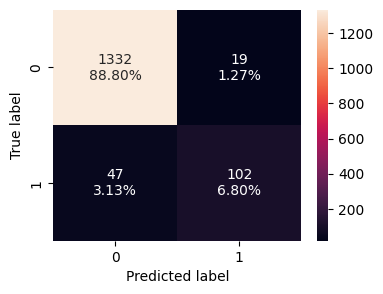

In [70]:
# creating confusion matrix
print("Testing Confusion Matrix")
confusion_matrix_sklearn_with_threshold(lg, X_test, y_test, threshold=0.35)

In [71]:
# checking model performance for this model
log_reg_model_test_perf_threshold_curve = (
    model_performance_classification_sklearn_with_threshold(
        lg, X_test, y_test, threshold=0.35
    )
)
print("Testing performance:")
log_reg_model_test_perf_threshold_curve

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.956,0.684564,0.842975,0.755556


use threshold around 0.30 and check the recall/precision for both training and testing data

Training Confusion Matrix


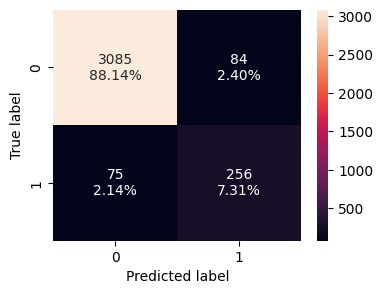

In [72]:
# creating confusion matrix
print("Training Confusion Matrix")
confusion_matrix_sklearn_with_threshold(lg, X_train, y_train, threshold=0.3)

In [73]:
# checking model performance for this model
log_reg_model_train_perf_threshold_curve_30 = (
    model_performance_classification_sklearn_with_threshold(
        lg, X_train, y_train, threshold=0.3
    )
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve_30

Training performance:


,Accuracy,Recall,Precision,F1
0,0.954571,0.773414,0.752941,0.76304


Testing Confusion Matrix


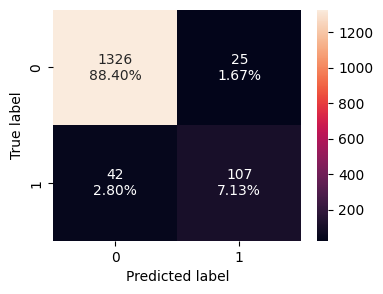

In [74]:
# creating confusion matrix
print("Testing Confusion Matrix")
confusion_matrix_sklearn_with_threshold(lg, X_test, y_test, threshold=0.3)

In [75]:
# checking model performance for this model
log_reg_model_test_perf_threshold_curve_30 = (
    model_performance_classification_sklearn_with_threshold(
        lg, X_test, y_test, threshold=0.3
    )
)
print("Testing performance:")
log_reg_model_test_perf_threshold_curve_30

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.955333,0.718121,0.810606,0.761566


### Logistic Regression - Model Performance Summary

In [76]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_class_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
        log_reg_model_train_perf_threshold_curve_30.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression Class",
    "Logistic Regression-Auc_Roc",
    "Logistic Regression-Threshold_35",
    "Logistic Regression-Threshold_30",
]

print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression Class,0.960286,0.679758,0.872093,0.764007
Logistic Regression-Auc_Roc,0.937143,0.870091,0.619355,0.723618
Logistic Regression-Threshold_35,0.959714,0.764350,0.800633,0.782071
Logistic Regression-Threshold_30,0.954571,0.773414,0.752941,0.763040


In [77]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        log_reg_model_class_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
        log_reg_model_test_perf_threshold_curve_30.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression Class",
    "Logistic Regression-Auc_Roc",
    "Logistic Regression-Threshold_35",
    "Logistic Regression-Threshold_30",
]

print("Testing performance comparison:")
models_test_comp_df.T

Testing performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression Class,0.952667,0.597315,0.890000,0.714859
Logistic Regression-Auc_Roc,0.933333,0.812081,0.626943,0.707602
Logistic Regression-Threshold_35,0.956000,0.684564,0.842975,0.755556
Logistic Regression-Threshold_30,0.955333,0.718121,0.810606,0.761566


### Data split for Decision Tree

spliting the data again, as we don't want to create dummy variables for decision tree

In [78]:
X = loan.drop(["Personal_Loan"], axis=1)  
y = loan["Personal_Loan"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [80]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 3500
Number of rows in test data = 1500


In [81]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


### Build Decision Tree Model

In [82]:
dTree = DecisionTreeClassifier(criterion="gini", random_state=1)
dTree.fit(X_train, y_train)
dTree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

#### Model Performance on Training Data

In [83]:
decision_tree_perf_train = model_performance_classification_sklearn(
    dTree, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


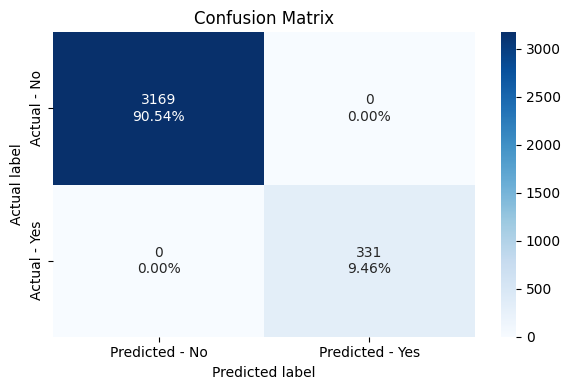

In [84]:
confusion_matrix_sklearn(dTree, X_train, y_train)

#### Model Performance on Testing Data

In [85]:
decision_tree_perf_test = model_performance_classification_sklearn(
    dTree, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.98,0.885906,0.910345,0.897959


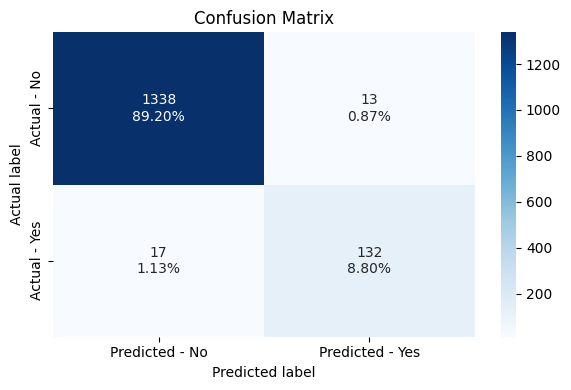

In [86]:
confusion_matrix_sklearn(dTree, X_test, y_test)

#### Visualizing Decision Tree Model

In [87]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


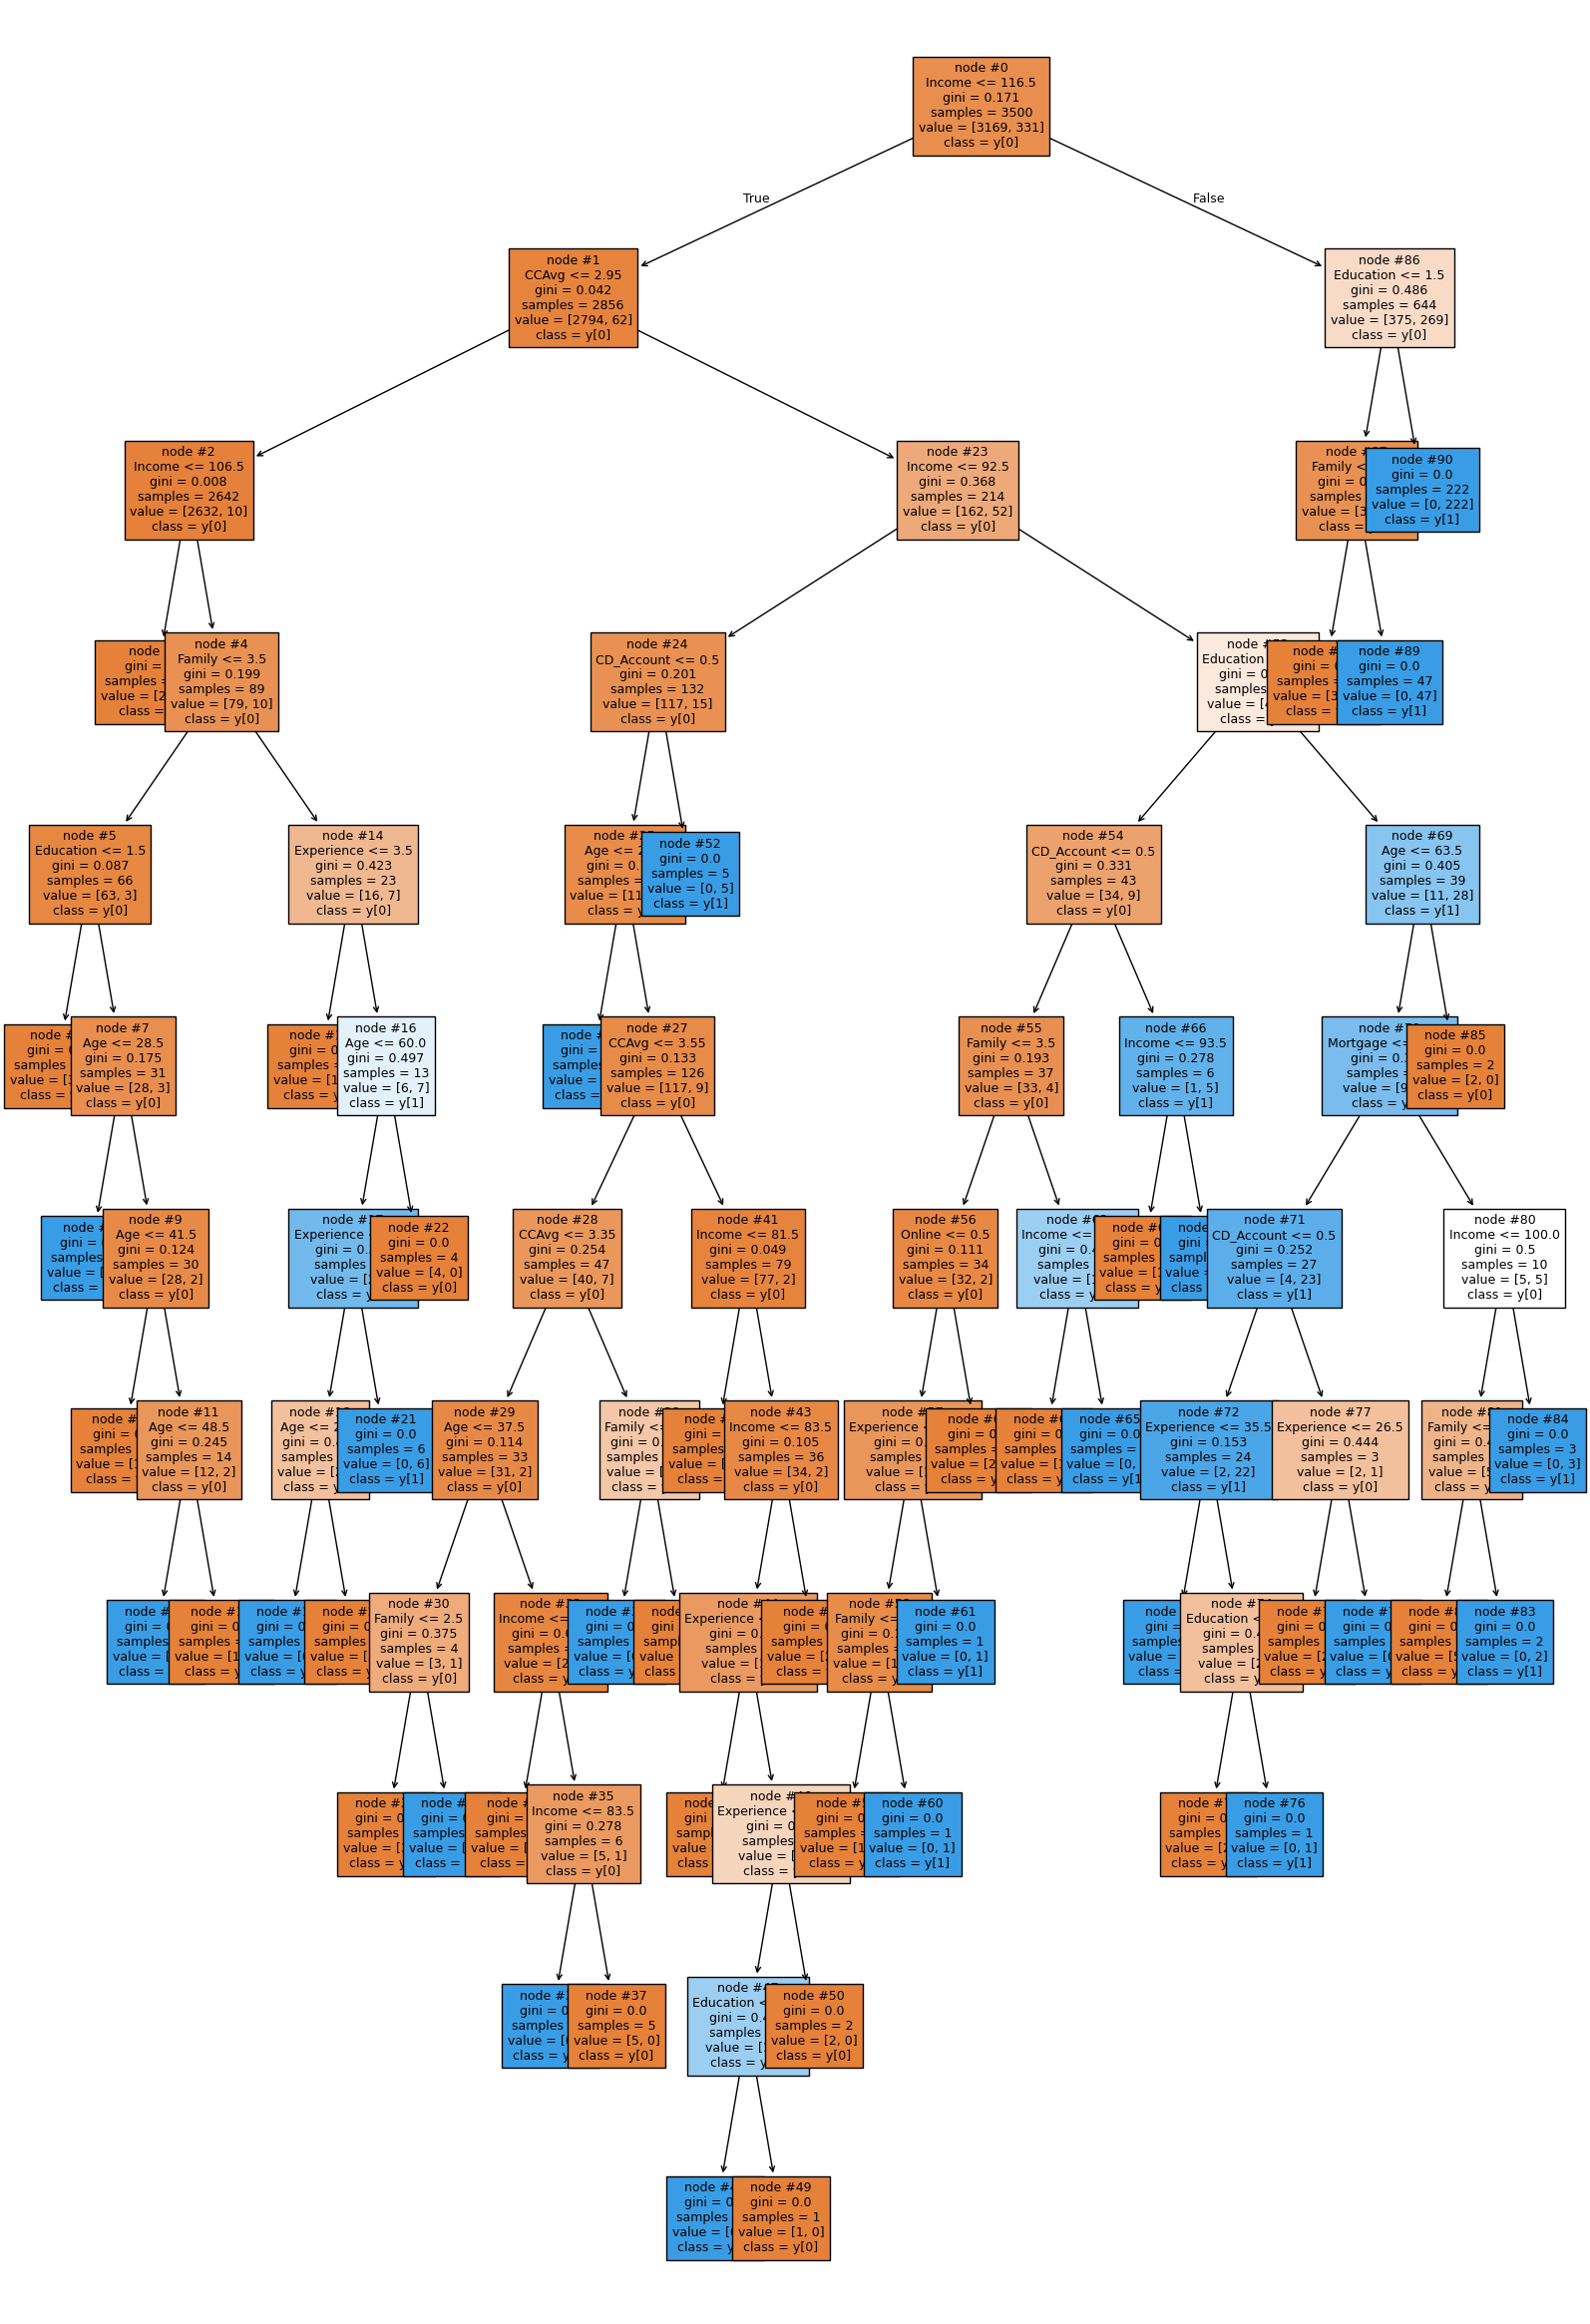

In [88]:
plt.figure(figsize=(20, 30))
tree.plot_tree(
    dTree,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

In [89]:
# Text report showing the rules of a decision tree -

print(tree.export_text(dTree, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [35.00, 0.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |--- Age <= 41.50
|   |   |   |   |   |   |   |--- weights: [16.00, 0.00] class: 0
|   |   |   |   |   |   |--- Age >  41.50
|   |   |   |   |   |   |   |--- Age <= 48.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |--- Age >  48.50
|   |   |   |   |   |   |   |   |--- weights: [12.00, 0.00] class: 0
|   |   |   |--- Family >  3.50
|   |   |   |   |--- Experience <= 3.50
|   |   |   |   |   |--- weights: [10.00, 0.00] class: 0
|   |   |   |   |--- Experience > 

In [90]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        dTree.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Education           0.405914
Income              0.310561
Family              0.167646
CCAvg               0.042183
CD_Account          0.025711
Age                 0.023880
Experience          0.020528
Mortgage            0.003014
Online              0.000561
Securities_Account  0.000000
CreditCard          0.000000


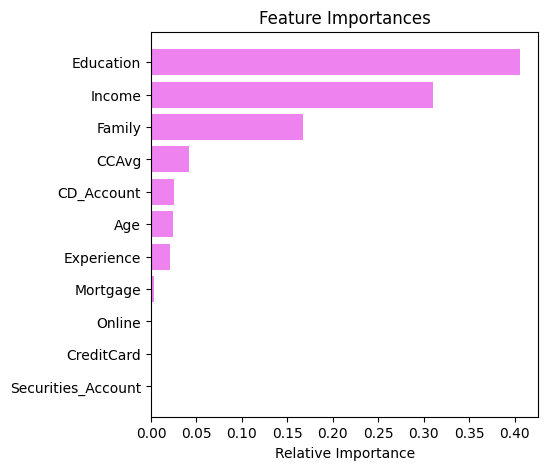

In [91]:
importances = dTree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(5, 5))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* According to the decision tree model, Education, Income, Family are three most important varable for predicting if the customer will take personal loan

### Build Decision Tree Model using GridSearch for Hyperparameter tuning

In [92]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {"max_depth": np.arange(1, 10)}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=3)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)
estimator.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': np.int64(7),
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

In [93]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.994571,0.954683,0.9875,0.970814


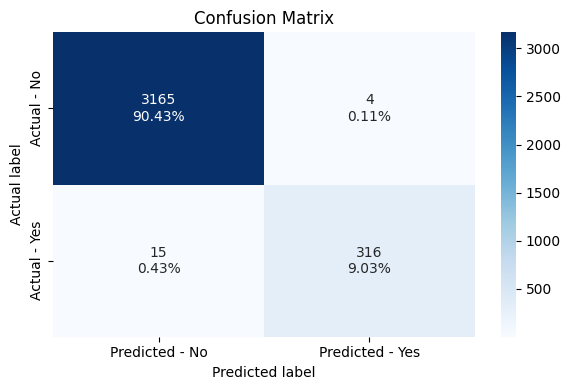

In [94]:
confusion_matrix_sklearn(estimator, X_train, y_train)

In [95]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.980667,0.872483,0.928571,0.899654


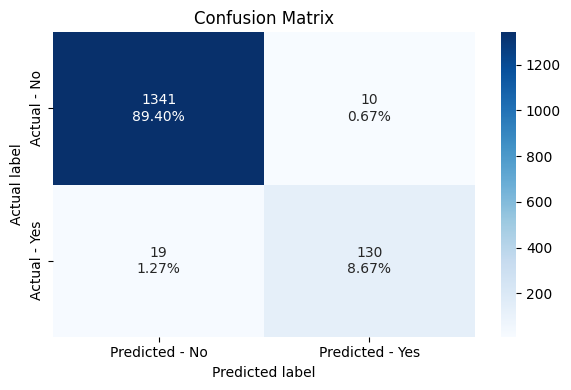

In [96]:
confusion_matrix_sklearn(estimator, X_test, y_test)

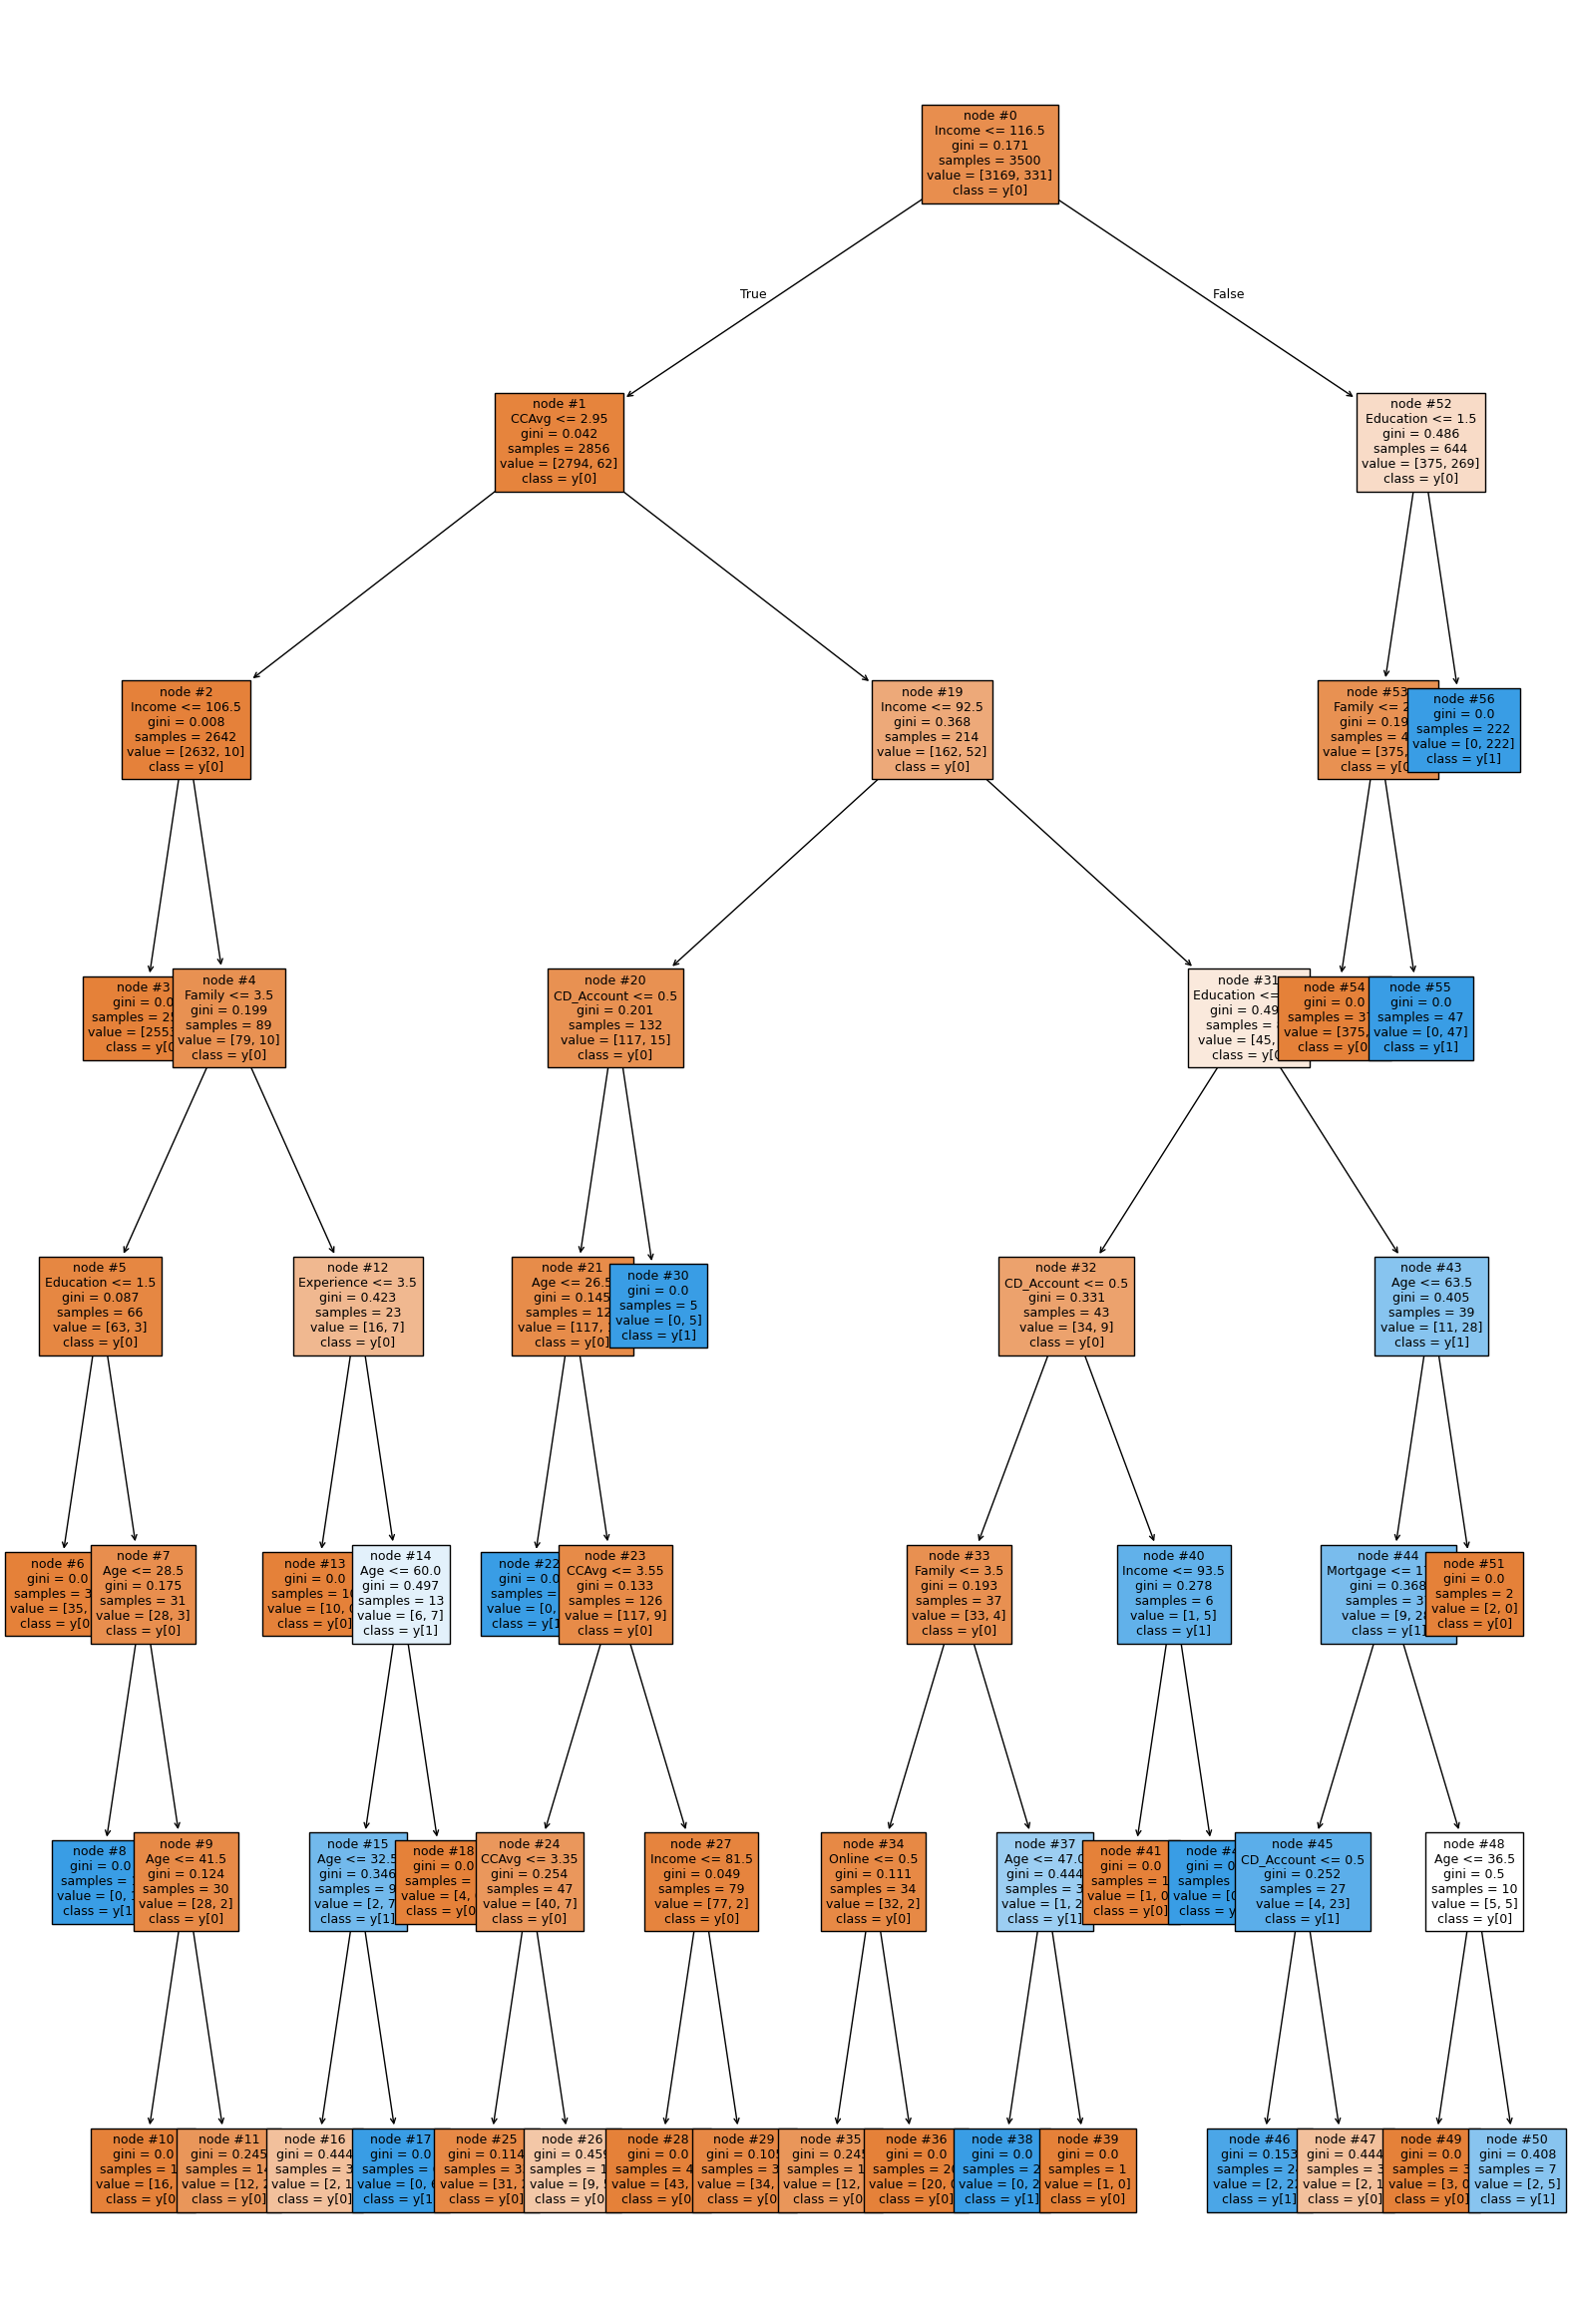

In [97]:
plt.figure(figsize=(20, 30))
tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

In [98]:
# importance
print(
    pd.DataFrame(
        estimator.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Education           0.422626
Income              0.316653
Family              0.154298
CCAvg               0.044406
CD_Account          0.027067
Age                 0.025430
Experience          0.005756
Mortgage            0.003173
Online              0.000590
Securities_Account  0.000000
CreditCard          0.000000


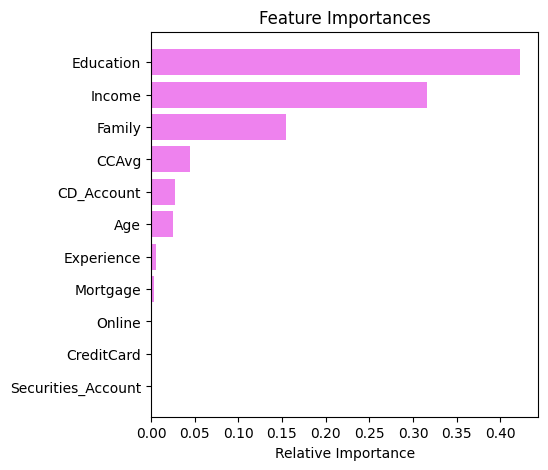

In [99]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(5, 5))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* After applying hyperparameter, decision tree suggests Education, Income and Family are most iportant factors in predicting a customer if they will take personal loan or not

### Cost Complexity Pruning

In [100]:
# get alphas and impurities at east step
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [101]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000223,0.001114
2,0.000268,0.002188
3,0.000359,0.003263
4,0.000381,0.003644
5,0.000381,0.004025
6,0.000381,0.004406
7,0.000381,0.004787
8,0.000409,0.006423
9,0.000476,0.006900


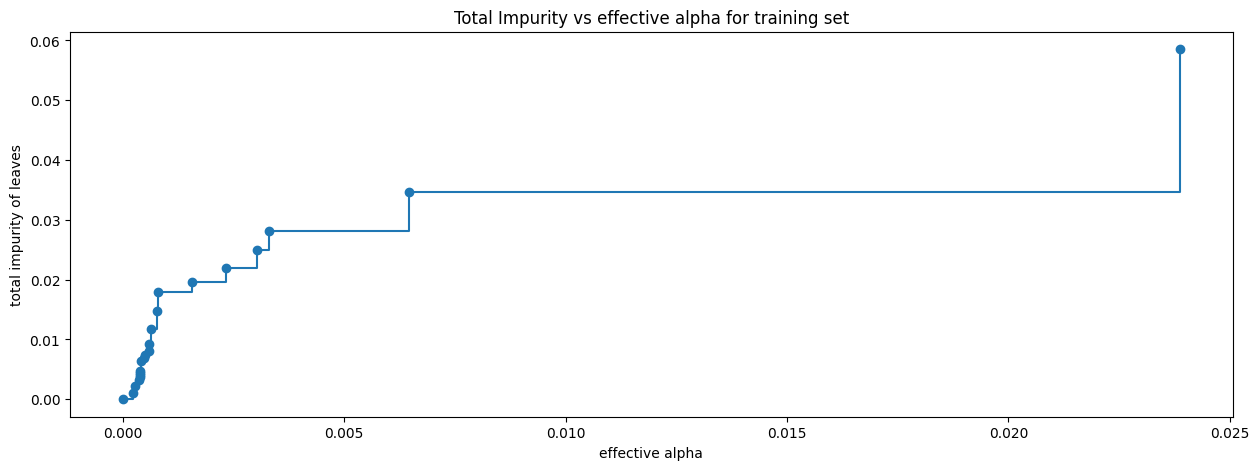

In [102]:
# plotting effective alpha vs total impurity of leaves
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [103]:
# training the decision tree using effective alphas
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.056364969335601575


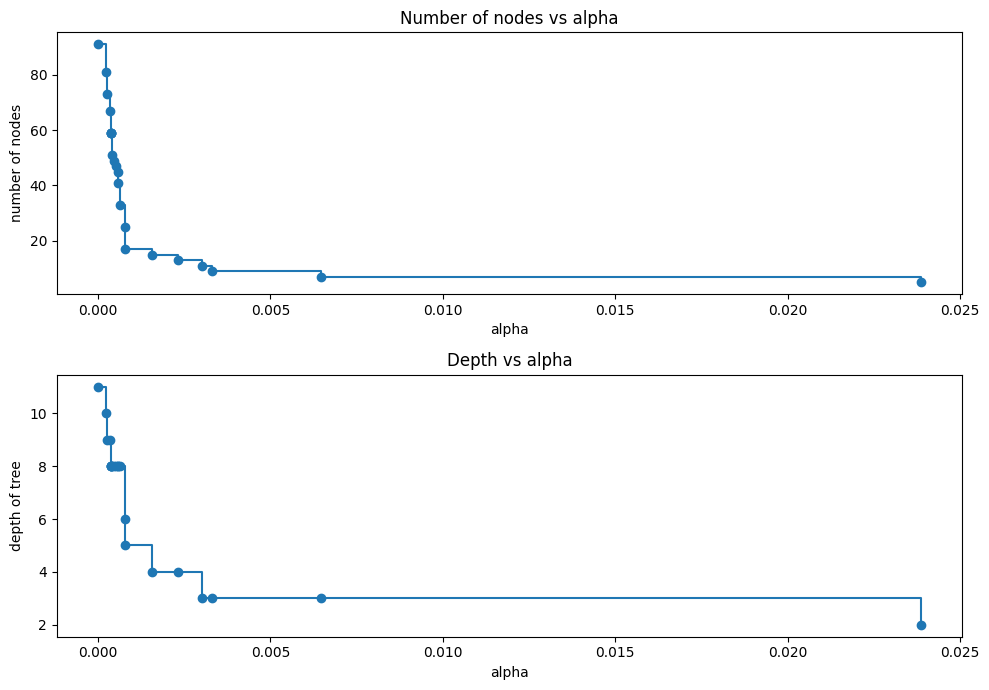

In [104]:
# we remove the last element in clfs and ccp_alphas as it is trivial tree with only one node.
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [105]:
# Accuracy vs alpha for training and testing sets

train_scores = [clf.score(X_train, y_train) for clf in clfs]
print(train_scores)
print()
test_scores = [clf.score(X_test, y_test) for clf in clfs]
print(test_scores)

[1.0, 0.9994285714285714, 0.9988571428571429, 0.9982857142857143, 0.9971428571428571, 0.9971428571428571, 0.9971428571428571, 0.9971428571428571, 0.9962857142857143, 0.996, 0.9957142857142857, 0.9954285714285714, 0.9948571428571429, 0.9928571428571429, 0.9911428571428571, 0.9897142857142858, 0.9885714285714285, 0.9871428571428571, 0.9822857142857143, 0.9822857142857143, 0.9822857142857143, 0.9688571428571429]

[0.98, 0.98, 0.9806666666666667, 0.9813333333333333, 0.9806666666666667, 0.9806666666666667, 0.9806666666666667, 0.9806666666666667, 0.9813333333333333, 0.9813333333333333, 0.9813333333333333, 0.9806666666666667, 0.982, 0.984, 0.9826666666666667, 0.9813333333333333, 0.9813333333333333, 0.98, 0.9753333333333334, 0.9753333333333334, 0.9753333333333334, 0.962]


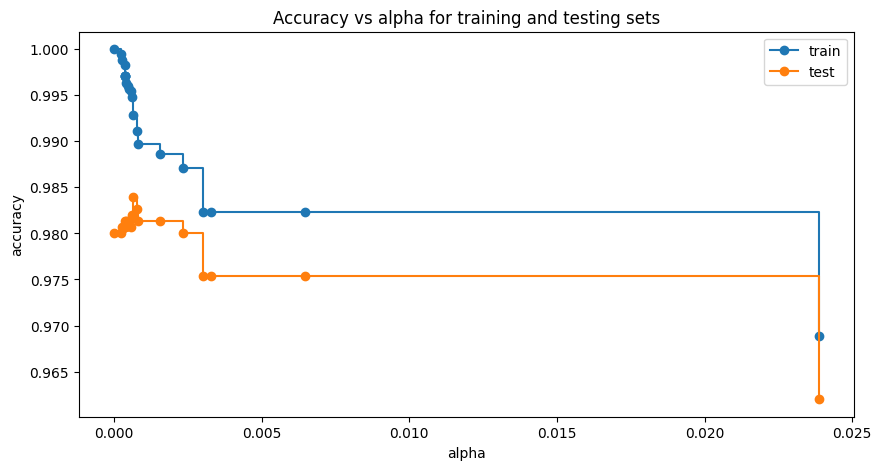

In [106]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [107]:
index_best_model = np.argmax(test_scores)
best_model = clfs[index_best_model]
print(best_model)
print("Training accuracy of best model: ", best_model.score(X_train, y_train))
print("Test accuracy of best model: ", best_model.score(X_test, y_test))

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006414326414326415),
                       random_state=1)
Training accuracy of best model:  0.9928571428571429
Test accuracy of best model:  0.984


Since accuracy isn't the right metric for our data, we would want high recall

In [108]:
recall_train = []
for clf in clfs:
    pred_train3 = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train3)
    recall_train.append(values_train)

In [109]:
recall_test = []
for clf in clfs:
    pred_test3 = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test3)
    recall_test.append(values_test)

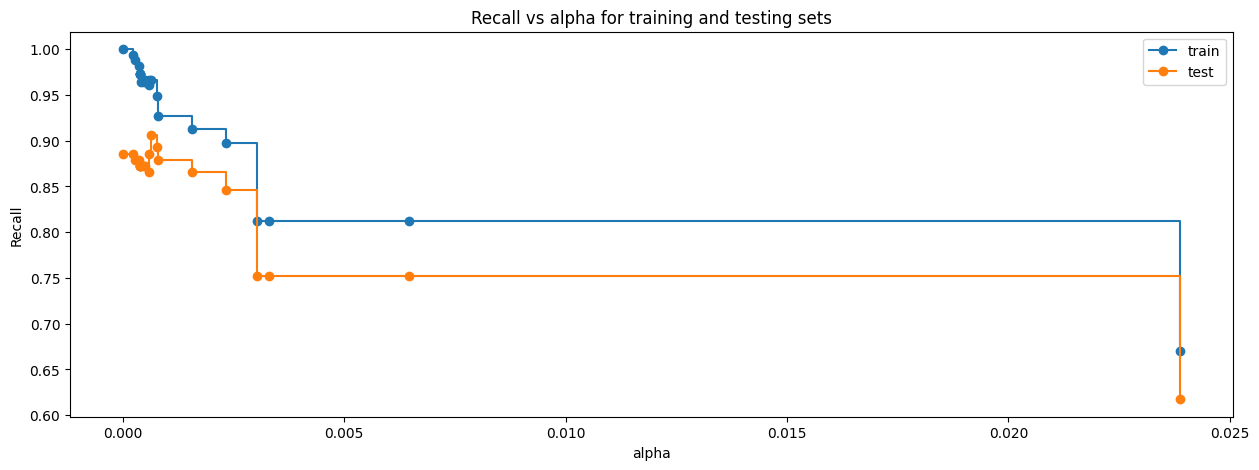

In [110]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [111]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006414326414326415),
                       random_state=1)


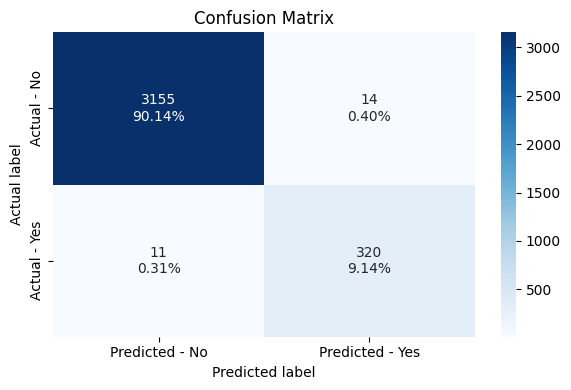

In [112]:
confusion_matrix_sklearn(best_model, X_train, y_train)

In [113]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.992857,0.966767,0.958084,0.962406


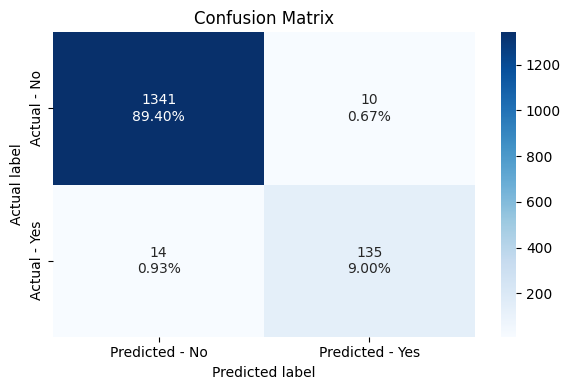

In [114]:
confusion_matrix_sklearn(best_model, X_test, y_test)

In [115]:
decision_tree_post_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.984,0.90604,0.931034,0.918367


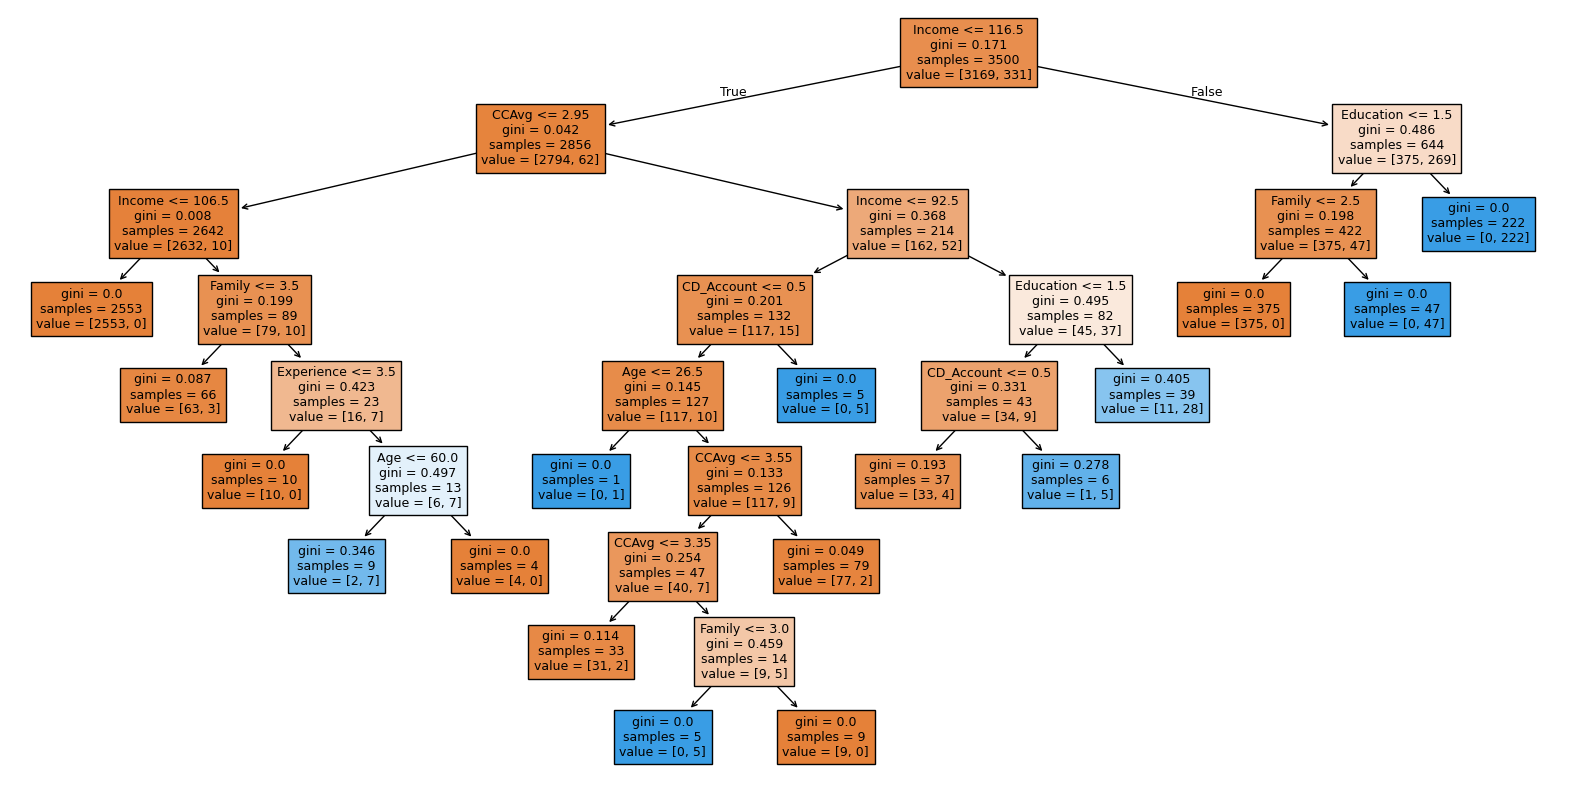

In [116]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [117]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

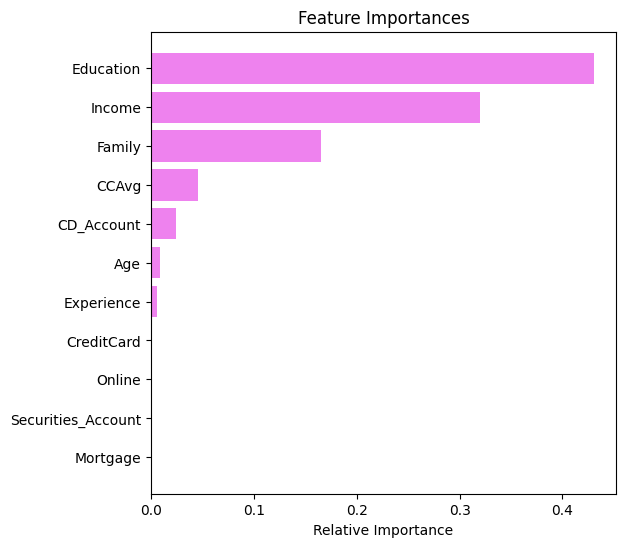

In [118]:
plt.figure(figsize=(6, 6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Post pruning also gives Education, Income and Family as most import in deciding if the customer will take personal loan

### Decision Treen - Model Performance Summary

In [119]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree with class",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree with class,1.000000,1.000000,1.000000,1.000000
Decision Tree (Pre-Pruning),0.994571,0.954683,0.987500,0.970814
Decision Tree (Post-Pruning),0.992857,0.966767,0.958084,0.962406


In [120]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree with class",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df.T

Test set performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree with class,0.980000,0.885906,0.910345,0.897959
Decision Tree (Pre-Pruning),0.980667,0.872483,0.928571,0.899654
Decision Tree (Post-Pruning),0.984000,0.906040,0.931034,0.918367


### Overall Performance

#### On Training

In [121]:
# training performance comparison

models_train_comp_Overall = pd.concat(
    [
        log_reg_model_class_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
        log_reg_model_train_perf_threshold_curve_30.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_Overall.columns = [
    "Logistic Regression Class",
    "Logistic Regression-Auc_Roc",
    "Logistic Regression-Threshold_35",
    "Logistic Regression-Threshold_30",
    "Decision Tree with class",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_Overall.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression Class,0.960286,0.679758,0.872093,0.764007
Logistic Regression-Auc_Roc,0.937143,0.870091,0.619355,0.723618
Logistic Regression-Threshold_35,0.959714,0.764350,0.800633,0.782071
Logistic Regression-Threshold_30,0.954571,0.773414,0.752941,0.763040
Decision Tree with class,1.000000,1.000000,1.000000,1.000000
Decision Tree (Pre-Pruning),0.994571,0.954683,0.987500,0.970814
Decision Tree (Post-Pruning),0.992857,0.966767,0.958084,0.962406


#### On Testing

In [122]:
# testing performance comparison

models_test_comp_Overall = pd.concat(
    [
        log_reg_model_class_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
        log_reg_model_test_perf_threshold_curve_30.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_Overall.columns = [
    "Logistic Regression Class",
    "Logistic Regression-Auc_Roc",
    "Logistic Regression-Threshold_35",
    "Logistic Regression-Threshold_30",
    "Decision Tree with class",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_Overall.T

Test set performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression Class,0.952667,0.597315,0.890000,0.714859
Logistic Regression-Auc_Roc,0.933333,0.812081,0.626943,0.707602
Logistic Regression-Threshold_35,0.956000,0.684564,0.842975,0.755556
Logistic Regression-Threshold_30,0.955333,0.718121,0.810606,0.761566
Decision Tree with class,0.980000,0.885906,0.910345,0.897959
Decision Tree (Pre-Pruning),0.980667,0.872483,0.928571,0.899654
Decision Tree (Post-Pruning),0.984000,0.906040,0.931034,0.918367


* Decision tree seems to give better recall, precision and F1 scores
* In the current context, based on the data, Decision Tree with Post Pruning gives best Recall for both training and test data

### Overall Recommendations:
* Key variables which impact personal loan are Education, Income and Family
* Bank should focus on customers with higher education for personal loans (Customers who are undergrads did not take personal loans as much as compared with customers who are graduates and have advanced degrees)
* Bank should focus on giving personal loans for Family with 4 and 3 members
* Bank should target higher Income customers for personal loans
* Bank should target credit card spenders in a month took for personal loans
* Bank should target customers who have mortgages for personal loans
* Bank shoudl target customers with certificate of deposit account for personal loan

### **Thank You**